# Credit Card Fraud Detection
**Dataset:** [mlg-ulb/creditcardfraud](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)  
**Target:** `Class` — 0 = Legitimate, 1 = Fraudulent  
**Features:** `Time`, `Amount`, `V1`–`V28` (PCA-transformed)

## 1: Understanding & Framing

### Business Context and Data Science Problem
A financial institution wants to improve how it detects potentially fraudulent card transactions using historical transaction data. The goal is not to replace all existing controls, but to add a machine learning risk-scoring capability that can help identify suspicious transactions more accurately than a rules-only approach. Rules-based systems are often useful as a first layer, but they can be rigid, generate unnecessary false positives, and struggle to adapt when fraud patterns change. A supervised machine learning model can complement rules by learning statistical patterns associated with fraudulent behavior and assigning a risk score to each transaction.

The data science problem is to build a model that predicts whether a transaction is fraudulent or legitimate using historical labeled examples. This is a binary classification problem because the target variable has two classes: legitimate transaction and fraudulent transaction. The model output should be a fraud risk score or probability rather than only a hard class prediction. That score can then support downstream actions such as approve, flag for review, request step-up verification, or decline, depending on the operating threshold and business policy.

### Type of Machine Learning to be Used
We will treat fraudulent transaction detection as a supervised binary classification problem using historical labeled transaction data. The objective is to generate a fraud risk score for each transaction that helps the institution detect more fraud, reduce unnecessary false positives, and support better downstream decisions under severe class imbalance.

- **Primary task:** Supervised binary classification  
- **Prediction target:** Class, where 0 = legitimate and 1 = fraud  
- **Prediction output:** A probability or ranking score indicating fraud risk  

This is the appropriate ML model to use since historical labels are available. Moreover, the business ultimately needs transaction-level decisions or prioritization. Lastly, fraud is rare, so ranking and thresholding are more useful than a simple default classifier.

### Success Matrix

| Metric | Proposed Success Criterion | Why It Matters |
|---|---|---|
| PR-AUC | Model must materially outperform a baseline rules model or a simple logistic baseline | PR-AUC is useful for rare-event detection, but absolute values can be hard to interpret without a baseline |
| Recall | At least 80% of known fraud captured in offline evaluation | Ensures the model catches a large share of fraud cases |
| Precision | At least 10% precision in flagged transactions, or better than the current review process baseline | Prevents overwhelming analysts with low-quality alerts |
| Recall at fixed FPR | At least 70% recall when FPR is capped at 0.5% | Aligns fraud capture with customer-friction limits |
| Top 1% capture rate | Top 1% highest-risk transactions should contain at least 60% of fraud cases | Measures ranking effectiveness for investigation queues |
| False Positive Rate | Must remain below 0.5% in the selected operating point | Keeps legitimate customer disruption under control |
| Cost-based metric | Selected threshold must reduce estimated total cost versus baseline | Connects model choice to business value |

### Business KPI
- Increase the share of fraudulent transactions identified before loss occurs.
- Reduce unnecessary friction on legitimate customers by limiting false positives.
- Improve analyst efficiency by ranking the most suspicious transactions higher.

However, these caveats might impact KPI measurement:

- **Class imbalance:** Fraud is rare, so training and evaluation must account for skewed labels.
- **Concept drift:** Fraud strategies change over time, so a model that works well today may degrade later.
- **Label delay:** In real systems, confirmed fraud labels may arrive after investigations or chargebacks, which complicates training and monitoring.
- **Interpretability:** Some level of explanation is usually needed for governance, analyst trust, and regulated decision processes, although exact legal requirements depend on how automated decisions are used in practice.




## 2. Data Collection and Understanding

### Data Overview
**Background:**  
The selected dataset is the Kaggle Credit Card Fraud Detection dataset from the ULB machine learning group. It contains transactions made by European cardholders in September 2013, covering two days of activity, with 284,807 total transactions and 492 fraud cases (fraud rate ≈ 0.172%).

This dataset is appropriate for demonstrating an end-to-end fraud detection workflow because it is well known, structured, highly imbalanced, and already labeled.

At the same time, it has important limitations:
- Original feature meanings are hidden for confidentiality.
- The data reflects an older, short time window, not a full modern production environment.

### Feature Summary

| Feature group | Variables | Type | Notes |
|---|---|---|---|
| Elapsed time | Time | Numerical | Seconds elapsed since the first transaction in the dataset. |
| PCA components | V1–V28 | Numerical | Anonymized principal components derived from original confidential variables. |
| Transaction amount | Amount | Numerical | Monetary value of the transaction. |
| Target label | Class | Binary integer | 0 = legitimate, 1 = fraud. |

### Feature Type Distribution

| Category | Count | Variables |
|---|---:|---|
| Numerical predictors | 30 | Time, V1–V28, Amount |
| Binary target | 1 | Class |
| Categorical features | 0 | None in the released dataset |
| Text features | 0 | None |
| Datetime features | 0 | Time is elapsed seconds, not a calendar timestamp |

### Missing Values

| Variable set | Expected missing values | Interpretation |
|---|---:|---|
| Time | 0 | Fully populated numerical field in the released dataset. |
| V1–V28 | 0 | PCA component fields are expected to be complete. |
| Amount | 0 | No missing values expected in the released dataset. |
| Class | 0 | Target label is expected to be complete. |

### Class Distribution

| Class | Count | Share |
|---|---:|---:|
| Legitimate (0) | 284,315 | 99.828% |
| Fraud (1) | 492 | 0.172% |

### Data Dictionary

| Variable | Type | Format / Unit | Expected or observed values | Description |
|---|---|---|---|---|
| Time | Numerical | Seconds elapsed | Non-negative continuous value | Seconds between current transaction and first transaction in the dataset |
| V1–V28 | Numerical | PCA component | Continuous real-valued fields | Anonymized principal components derived from confidential original features |
| Amount | Numerical | Currency amount | Non-negative continuous value | Monetary value of the transaction |
| Class | Binary integer | 0 or 1 | 0 = legitimate, 1 = fraud | Target variable for supervised fraud detection |

Overall, this dataset is a strong choice for demonstrating the ML lifecycle for fraud detection. It has labeled outcomes, realistic imbalance, and a clear binary target. Its main limitations are that most features are anonymized PCA components and that the sample is short and dated. Therefore, conclusions about business interpretation or modern production deployment should be made carefully.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_theme(style='whitegrid')

DATA_PATH = 'data/creditcard.csv'

In [2]:
df = pd.read_csv(DATA_PATH)

print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
df.head()

Shape: (284807, 31)
Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0000,-1.3598,-0.0728,2.5363,1.3782,-0.3383,0.4624,0.2396,0.0987,0.3638,...,-0.0183,0.2778,-0.1105,0.0669,0.1285,-0.1891,0.1336,-0.0211,149.6200,0
1,0.0000,1.1919,0.2662,0.1665,0.4482,0.0600,-0.0824,-0.0788,0.0851,-0.2554,...,-0.2258,-0.6387,0.1013,-0.3398,0.1672,0.1259,-0.0090,0.0147,2.6900,0
2,1.0000,-1.3584,-1.3402,1.7732,0.3798,-0.5032,1.8005,0.7915,0.2477,-1.5147,...,0.2480,0.7717,0.9094,-0.6893,-0.3276,-0.1391,-0.0554,-0.0598,378.6600,0
3,1.0000,-0.9663,-0.1852,1.7930,-0.8633,-0.0103,1.2472,0.2376,0.3774,-1.3870,...,-0.1083,0.0053,-0.1903,-1.1756,0.6474,-0.2219,0.0627,0.0615,123.5000,0
4,2.0000,-1.1582,0.8777,1.5487,0.4030,-0.4072,0.0959,0.5929,-0.2705,0.8177,...,-0.0094,0.7983,-0.1375,0.1413,-0.2060,0.5023,0.2194,0.2152,69.9900,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [4]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,...,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000
mean,94813.8596,0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,-0.0000,...,0.0000,-0.0000,0.0000,0.0000,0.0000,0.0000,-0.0000,-0.0000,88.3496,0.0017
std,47488.1460,1.9587,1.6513,1.5163,1.4159,1.3802,1.3323,1.2371,1.1944,1.0986,...,0.7345,0.7257,0.6245,0.6056,0.5213,0.4822,0.4036,0.3301,250.1201,0.0415
min,0.0000,-56.4075,-72.7157,-48.3256,-5.6832,-113.7433,-26.1605,-43.5572,-73.2167,-13.4341,...,-34.8304,-10.9331,-44.8077,-2.8366,-10.2954,-2.6046,-22.5657,-15.4301,0.0000,0.0000
25%,54201.5000,-0.9204,-0.5985,-0.8904,-0.8486,-0.6916,-0.7683,-0.5541,-0.2086,-0.6431,...,-0.2284,-0.5424,-0.1618,-0.3546,-0.3171,-0.3270,-0.0708,-0.0530,5.6000,0.0000
50%,84692.0000,0.0181,0.0655,0.1798,-0.0198,-0.0543,-0.2742,0.0401,0.0224,-0.0514,...,-0.0295,0.0068,-0.0112,0.0410,0.0166,-0.0521,0.0013,0.0112,22.0000,0.0000
75%,139320.5000,1.3156,0.8037,1.0272,0.7433,0.6119,0.3986,0.5704,0.3273,0.5971,...,0.1864,0.5286,0.1476,0.4395,0.3507,0.2410,0.0910,0.0783,77.1650,0.0000
max,172792.0000,2.4549,22.0577,9.3826,16.8753,34.8017,73.3016,120.5895,20.0072,15.5950,...,27.2028,10.5031,22.5284,4.5845,7.5196,3.5173,31.6122,33.8478,25691.1600,1.0000


## 3a. Data Cleaning

### 3a.1 Missing Values

In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_report = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).query('`Missing Count` > 0')

if missing_report.empty:
    print('No missing values found.')
else:
    print(missing_report)
    # Impute numeric columns with median
    for col in missing_report.index:
        df[col].fillna(df[col].median(), inplace=True)
    print(f'Imputed {len(missing_report)} column(s) with median.')

No missing values found.


### 3a.2 Remove Duplicates

In [6]:
n_duplicates = df.duplicated().sum()
print(f'Duplicate rows found: {n_duplicates}')

if n_duplicates > 0:
    df.drop_duplicates(inplace=True)
    df.reset_index(drop=True, inplace=True)
    print(f'Removed {n_duplicates} duplicate(s). New shape: {df.shape}')
else:
    print('No duplicates to remove.')

Duplicate rows found: 1081
Removed 1081 duplicate(s). New shape: (283726, 31)


### 3c.3 Addrerss Outliers

We apply outlier treatment **only to `Amount` and `Time`** — the raw, non-PCA features.  
The `V1`–`V28` features are already PCA-transformed by the dataset authors; capping them further would distort the latent structure.

**Method:** IQR-based capping (Winsorization) — outliers are clipped to the 1st / 99th percentile bounds rather than dropped, preserving row count.

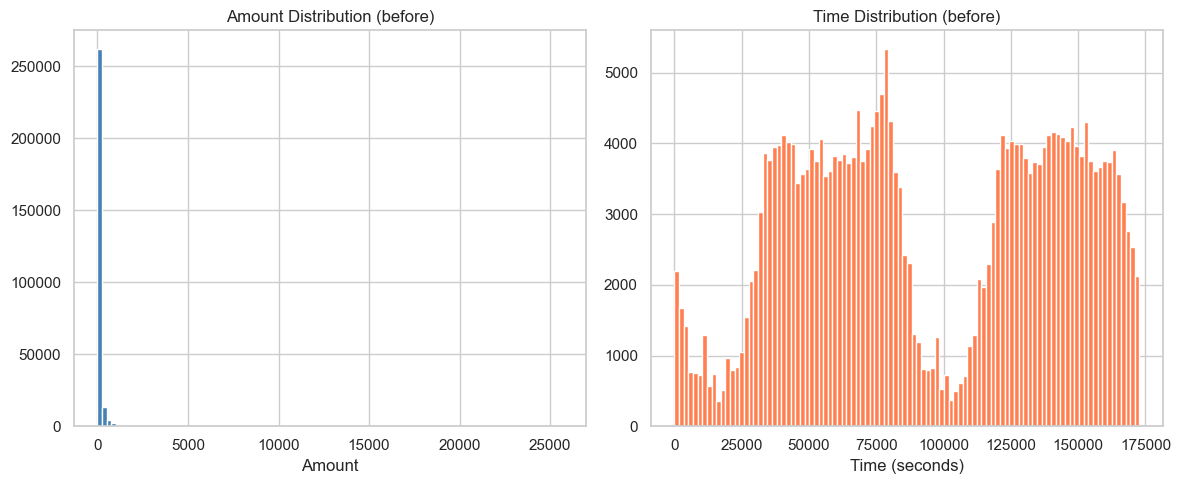

          min         max       mean     median  skewness
Amount 0.0000  25691.1600    88.4727    22.0000   16.9788
Time   0.0000 172792.0000 94811.0776 84692.5000   -0.0356


In [7]:
# Visualise Amount and Time distributions before treatment
fig, axes = plt.subplots(1, 2)
df['Amount'].hist(bins=100, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Amount Distribution (before)')
axes[0].set_xlabel('Amount')

df['Time'].hist(bins=100, ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Time Distribution (before)')
axes[1].set_xlabel('Time (seconds)')

plt.tight_layout()
plt.show()

cols = ['Amount', 'Time']

summary_stats = pd.DataFrame({
    'min': df[cols].min(),
    'max': df[cols].max(),
    'mean': df[cols].mean(),
    'median': df[cols].median(),
    'skewness': df[cols].skew()
}).round(6)

print(summary_stats)

### Histogram Interpretation (Before Outlier Treatment)

#### 1. `Amount Distribution (before)`
- The histogram is **strongly right-skewed** (long tail to the right).
- Most transactions are small amounts, while a few transactions are very large.
- Evidence from summary stats:
  - Median = `22.0`
  - Max = `25691.16`
  - Skewness ≈ `16.98` (very high positive skew)
- In the plot, this appears as tall bars near low values and sparse bars extending far right.

#### 2. `Time Distribution (before)`
- The histogram is **roughly balanced / near-symmetric** across its range.
- It does not show the same extreme one-sided tail as `Amount`.
- Evidence from summary stats:
  - Min = `0`
  - Max = `172792`
  - Skewness ≈ `-0.036` (close to zero)
- In the plot, values are spread more evenly across the timeline.

#### Why This Matters
- The `Amount` feature clearly has heavy-tailed behavior, so outlier capping is especially justified.
- `Time` is less extreme but can still be capped for robustness.

In [8]:
def iqr_outlier_report(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((series < lower) | (series > upper)).sum()
    return lower, upper, n_out

for col in ['Amount', 'Time']:
    lower, upper, n_out = iqr_outlier_report(df[col])
    print(f'{col}: {n_out} outliers | IQR bounds [{lower:.2f}, {upper:.2f}]')

Amount: 31685 outliers | IQR bounds [-102.27, 185.38]
Time: 0 outliers | IQR bounds [-73435.12, 266937.88]


In [9]:
# Winsorize Amount and Time at 1st / 99th percentiles
for col in ['Amount', 'Time']:
    p01 = df[col].quantile(0.01)
    p99 = df[col].quantile(0.99)
    df[col] = df[col].clip(lower=p01, upper=p99)
    print(f'{col} clipped to [{p01:.2f}, {p99:.2f}]')

Amount clipped to [0.12, 1018.97]
Time clipped to [2426.25, 170557.75]


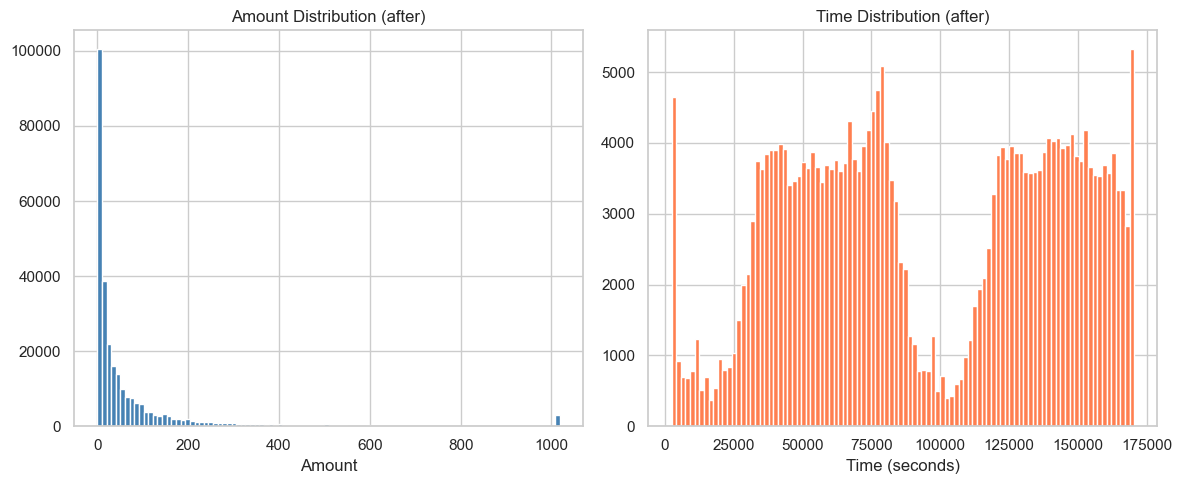

             min         max       mean     median  skewness
Amount    0.1200   1018.9650    80.3042    22.0000    3.8092
Time   2426.2500 170557.7500 94813.5543 84692.5000   -0.0344


In [10]:
# Visualise Amount and Time distributions after treatment
fig, axes = plt.subplots(1, 2)
df['Amount'].hist(bins=100, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Amount Distribution (after)')
axes[0].set_xlabel('Amount')

df['Time'].hist(bins=100, ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Time Distribution (after)')
axes[1].set_xlabel('Time (seconds)')

plt.tight_layout()
plt.show()

cols = ['Amount', 'Time']

summary_stats = pd.DataFrame({
    'min': df[cols].min(),
    'max': df[cols].max(),
    'mean': df[cols].mean(),
    'median': df[cols].median(),
    'skewness': df[cols].skew()
}).round(6)

print(summary_stats)

In [11]:
print(f'Final shape : {df.shape}')
print(f'Missing values: {df.isnull().sum().sum()}')
print(f'Duplicates   : {df.duplicated().sum()}')
print()
print('Class distribution:')
print(df['Class'].value_counts())
print(f'Fraud rate: {df["Class"].mean()*100:.4f}%')

Final shape : (283726, 31)
Missing values: 0
Duplicates   : 19

Class distribution:
Class
0    283253
1       473
Name: count, dtype: int64
Fraud rate: 0.1667%


In [12]:
n_dup_after = df.duplicated().sum()
print(f"Duplicates after capping: {n_dup_after}")

if n_dup_after > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"Removed {n_dup_after} duplicates. New shape: {df.shape}")

print(f'Final shape : {df.shape}')
print(f'Missing values: {df.isnull().sum().sum()}')
print(f'Duplicates   : {df.duplicated().sum()}')
print()
print('Class distribution:')
print(df['Class'].value_counts())
print(f'Fraud rate: {df["Class"].mean()*100:.4f}%')

Duplicates after capping: 19
Removed 19 duplicates. New shape: (283707, 31)
Final shape : (283707, 31)
Missing values: 0
Duplicates   : 0

Class distribution:
Class
0    283234
1       473
Name: count, dtype: int64
Fraud rate: 0.1667%


---
## 3b. Exploratory Data Analysis (EDA)

### 3b.1 Univariate Analysis — Distributions

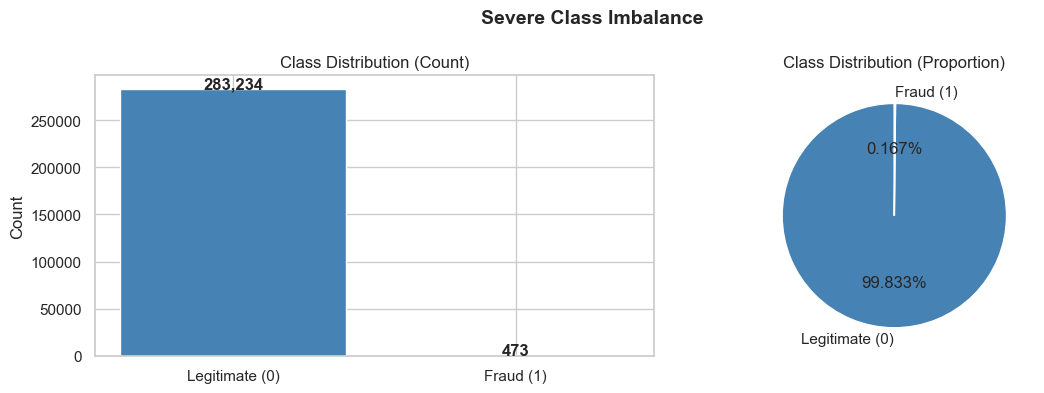

In [13]:
# Class imbalance
class_counts = df['Class'].value_counts()
class_labels = ['Legitimate (0)', 'Fraud (1)']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(class_labels, class_counts.values, color=['steelblue', 'crimson'], edgecolor='white')
axes[0].set_title('Class Distribution (Count)')
axes[0].set_ylabel('Count')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

axes[1].pie(class_counts.values, labels=class_labels, autopct='%1.3f%%',
            colors=['steelblue', 'crimson'], startangle=90)
axes[1].set_title('Class Distribution (Proportion)')

plt.suptitle('Severe Class Imbalance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Class Imbalance Plot Interpretation

This cell visualizes the target variable (`Class`) using two charts:

- **Bar chart (Count):** compares the number of `Legitimate (0)` vs `Fraud (1)` transactions.
- **Pie chart (Proportion):** shows the percentage share of each class.

#### What the output shows
- The dataset has a **severe class imbalance**.
- `Legitimate (0)` transactions dominate the dataset.
- `Fraud (1)` transactions are only a very small fraction (around **0.17%** based on earlier summary).

#### Why this matters
- Standard accuracy can be misleading in highly imbalanced data.
- Model evaluation should prioritize metrics such as:
  - **Precision**
  - **Recall**
  - **F1-score**
  - **PR-AUC** (especially important for rare-event detection)


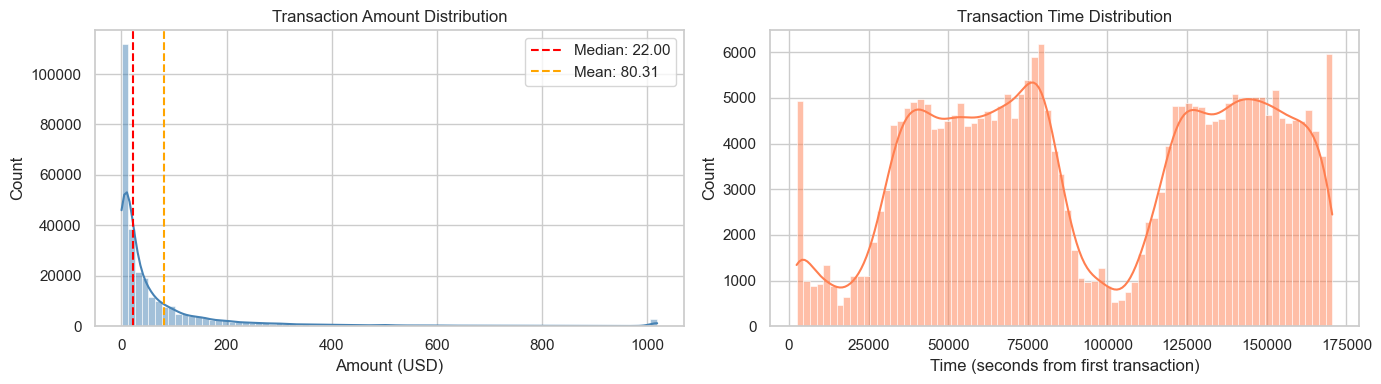

In [14]:
# Amount and Time distributions with KDE
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(df['Amount'], bins=80, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Transaction Amount Distribution')
axes[0].set_xlabel('Amount (USD)')
axes[0].axvline(df['Amount'].median(), color='red', linestyle='--', label=f'Median: {df["Amount"].median():.2f}')
axes[0].axvline(df['Amount'].mean(), color='orange', linestyle='--', label=f'Mean: {df["Amount"].mean():.2f}')
axes[0].legend()

sns.histplot(df['Time'], bins=80, kde=True, ax=axes[1], color='coral')
axes[1].set_title('Transaction Time Distribution')
axes[1].set_xlabel('Time (seconds from first transaction)')

plt.tight_layout()
plt.show()

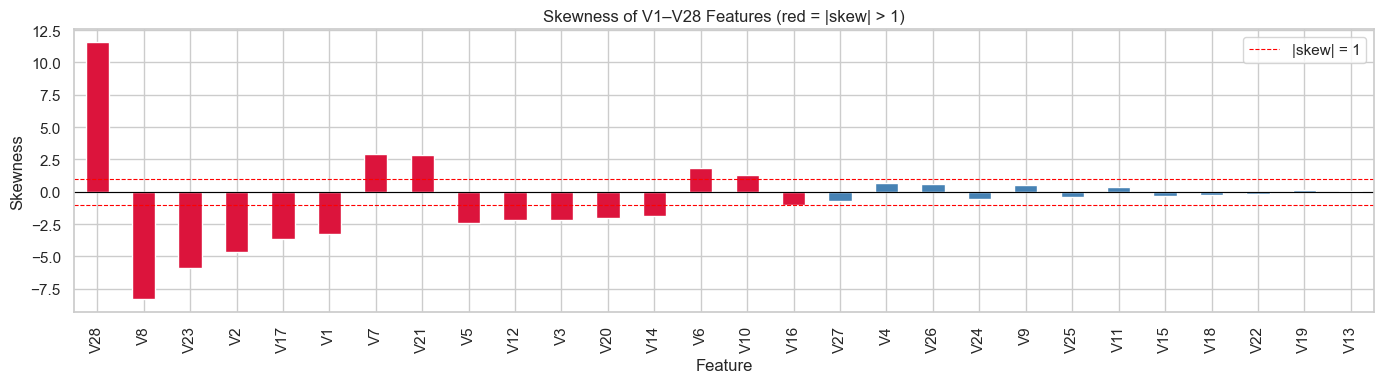

In [15]:
# V1–V28 skewness overview
v_features = [f'V{i}' for i in range(1, 29)]
skewness = df[v_features].skew().sort_values(key=abs, ascending=False)

plt.figure(figsize=(14, 4))
skewness.plot(kind='bar', color=[
    'crimson' if abs(s) > 1 else 'steelblue' for s in skewness
])
plt.axhline(0, color='black', linewidth=0.8)
plt.axhline(1, color='red', linestyle='--', linewidth=0.8, label='|skew| = 1')
plt.axhline(-1, color='red', linestyle='--', linewidth=0.8)
plt.title('Skewness of V1–V28 Features (red = |skew| > 1)')
plt.xlabel('Feature')
plt.ylabel('Skewness')
plt.legend()
plt.tight_layout()
plt.show()

#print('Top 5 most skewed features:')
#print(skewness.head)
#normal_skew = skewness[(skewness >= -1) & (skewness <= 1)]
#asymetric_skew = skewness[(skewness < -1) | (skewness > 1)]
#print(normal_skew)
#print(asymetric_skew)

### Output Explanation — Skewness of `V1`–`V28`

The chart visualizes the skewness of all PCA-based features (`V1` to `V28`), sorted by absolute skewness (most skewed first).

#### How to read the plot
- **Y-axis:** skewness value of each feature.
- **Black horizontal line at 0:** perfectly symmetric distribution.
- **Red dashed lines at +1 and -1:** threshold for strong skewness.
- **Bar colors:**
  - **Red:** `|skewness| > 1` (strongly skewed / asymmetric)
  - **Steel blue:** `|skewness| <= 1` (mild to moderate skew)

#### What this output tells us
- Several PCA features still show strong asymmetry, even after transformation.
- Features with bars beyond `+1` or `-1` are the most non-normal.
- This matters for models sensitive to distribution shape (e.g., linear models), while tree-based models are generally less affected.

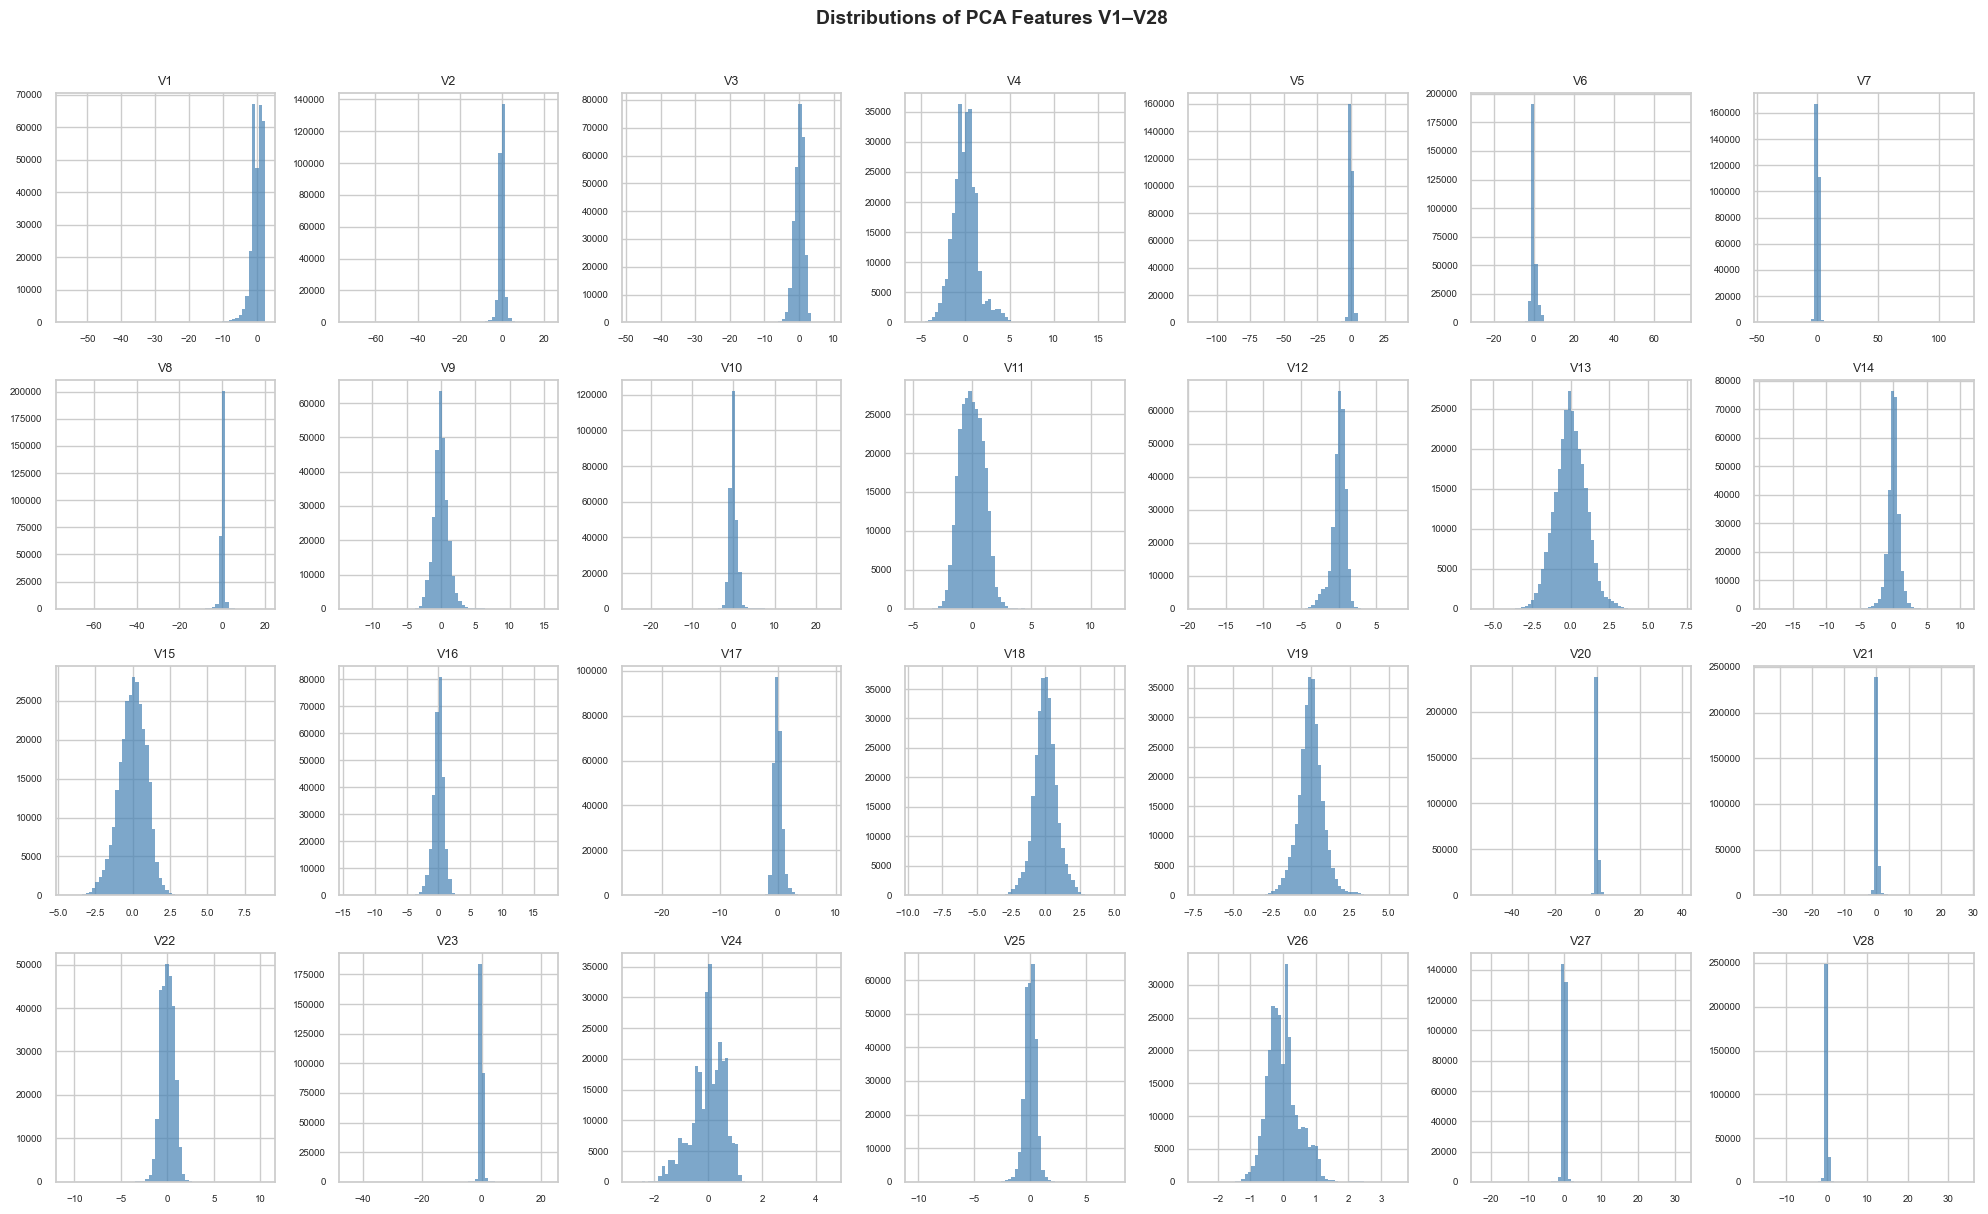

In [16]:
# Distribution grid for V1–V28
fig, axes = plt.subplots(4, 7, figsize=(20, 12))
axes = axes.flatten()

for i, col in enumerate(v_features):
    axes[i].hist(df[col], bins=60, color='steelblue', edgecolor='none', alpha=0.7)
    axes[i].set_title(col, fontsize=9)
    axes[i].tick_params(labelsize=7)

plt.suptitle('Distributions of PCA Features V1–V28', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 3b.2 Bivariate Analysis — Relationships with Class

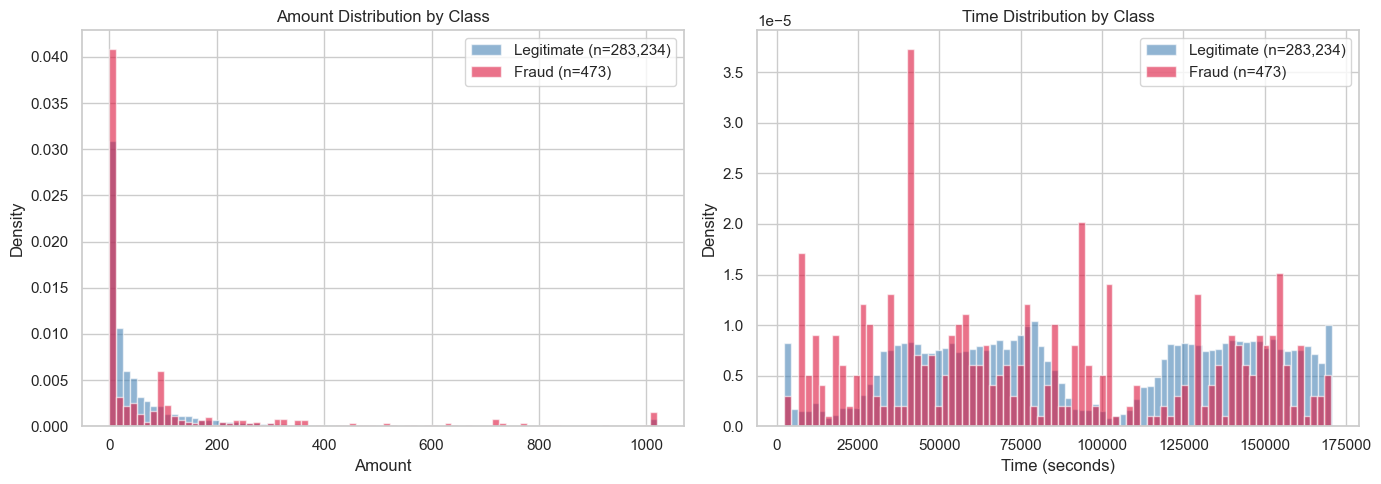

In [17]:
# Amount and Time distributions by Class
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for cls, label, color in [(0, 'Legitimate', 'steelblue'), (1, 'Fraud', 'crimson')]:
    subset = df[df['Class'] == cls]['Amount']
    axes[0].hist(subset, bins=80, alpha=0.6, label=f'{label} (n={len(subset):,})',
                 color=color, density=True)
axes[0].set_title('Amount Distribution by Class')
axes[0].set_xlabel('Amount')
axes[0].set_ylabel('Density')
axes[0].legend()

for cls, label, color in [(0, 'Legitimate', 'steelblue'), (1, 'Fraud', 'crimson')]:
    subset = df[df['Class'] == cls]['Time']
    axes[1].hist(subset, bins=80, alpha=0.6, label=f'{label} (n={len(subset):,})',
                 color=color, density=True)
axes[1].set_title('Time Distribution by Class')
axes[1].set_xlabel('Time (seconds)')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.tight_layout()
plt.show()

In [18]:
# Amount statistics by Class
print('Amount statistics by Class:')
print(df.groupby('Class')['Amount'].describe().round(2))

Amount statistics by Class:
            count     mean      std    min    25%     50%      75%       max
Class                                                                       
0     283234.0000  80.2500 159.3000 0.1200 5.6700 22.0000  77.4800 1018.9600
1        473.0000 115.2800 215.9600 0.1200 1.0000  9.8200 105.8900 1018.9600


### Insights from Amount/Time Distributions by Class

#### 1. `Amount` vs Class
- Fraud and legitimate transactions show substantial overlap in `Amount`.
- Fraud may concentrate differently in some low-to-mid amount ranges, but `Amount` alone is not a strong standalone separator.
- Interpretation: `Amount` is still useful, especially when combined with other predictors.

#### 2. `Time` vs Class
- The distribution of fraud over `Time` can differ from legitimate transactions across the timeline.
- This suggests temporal behavior has signal (for example, specific periods with relatively higher fraud density).
- Interpretation: time-based engineered features (e.g., time-of-day buckets) are justified.

#### 3. Modeling Implication
- Because there is strong overlap between classes, no single variable can cleanly separate fraud from non-fraud.
- Better performance should come from **multivariate models** and **feature interactions** (e.g., tree ensembles), with evaluation focused on imbalanced metrics (Precision/Recall, F1, PR-AUC).



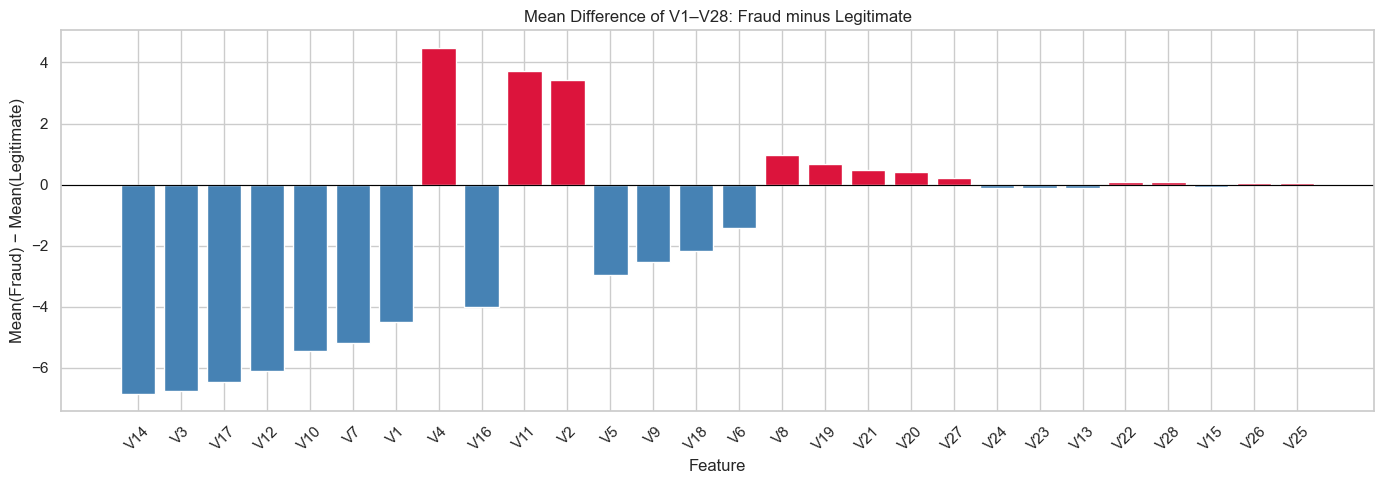

Top 5 features most different between classes:
V14   -6.8476
V3    -6.7425
V17   -6.4743
V12   -6.1127
V10   -5.4609
Name: Difference, dtype: float64


In [19]:
# Mean difference of V1–V28 between Fraud and Legitimate
v_means = df.groupby('Class')[v_features].mean().T
v_means.columns = ['Legitimate', 'Fraud']
v_means['Difference'] = v_means['Fraud'] - v_means['Legitimate']
v_means_sorted = v_means.reindex(v_means['Difference'].abs().sort_values(ascending=False).index)

plt.figure(figsize=(14, 5))
colors = ['crimson' if d > 0 else 'steelblue' for d in v_means_sorted['Difference']]
plt.bar(v_means_sorted.index, v_means_sorted['Difference'], color=colors)
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Mean Difference of V1–V28: Fraud minus Legitimate')
plt.xlabel('Feature')
plt.ylabel('Mean(Fraud) − Mean(Legitimate)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print('Top 5 features most different between classes:')
print(v_means_sorted['Difference'].head())

The analysis compares the average value of each PCA feature (`V1`–`V28`) between fraud and legitimate transactions.  
The largest absolute differences were:

- `V14 = -6.8476`
- `V3  = -6.7425`
- `V17 = -6.4743`
- `V12 = -6.1127`
- `V10 = -5.4609`

#### Why this is important
- These features show the **strongest class-level separation** in central tendency.
- The negative values mean fraud transactions have substantially **lower mean values** than legitimate ones for these components.
- This suggests these variables carry high discriminatory signal and are likely influential for classification.

#### Modeling implications
- `V14`, `V3`, `V17`, `V12`, and `V10` are strong candidates for:
  - feature selection priority,
  - model interpretation focus (e.g., feature importance / SHAP),
  - fraud-scoring rules or monitoring thresholds.
- Because these are PCA components, interpretation is statistical (latent behavior differences), not directly business-semantic.

#### Caveat
- Mean differences are univariate summaries and do not capture nonlinear interactions.
- Final feature value should still be validated through model-based importance and cross-validation performance.

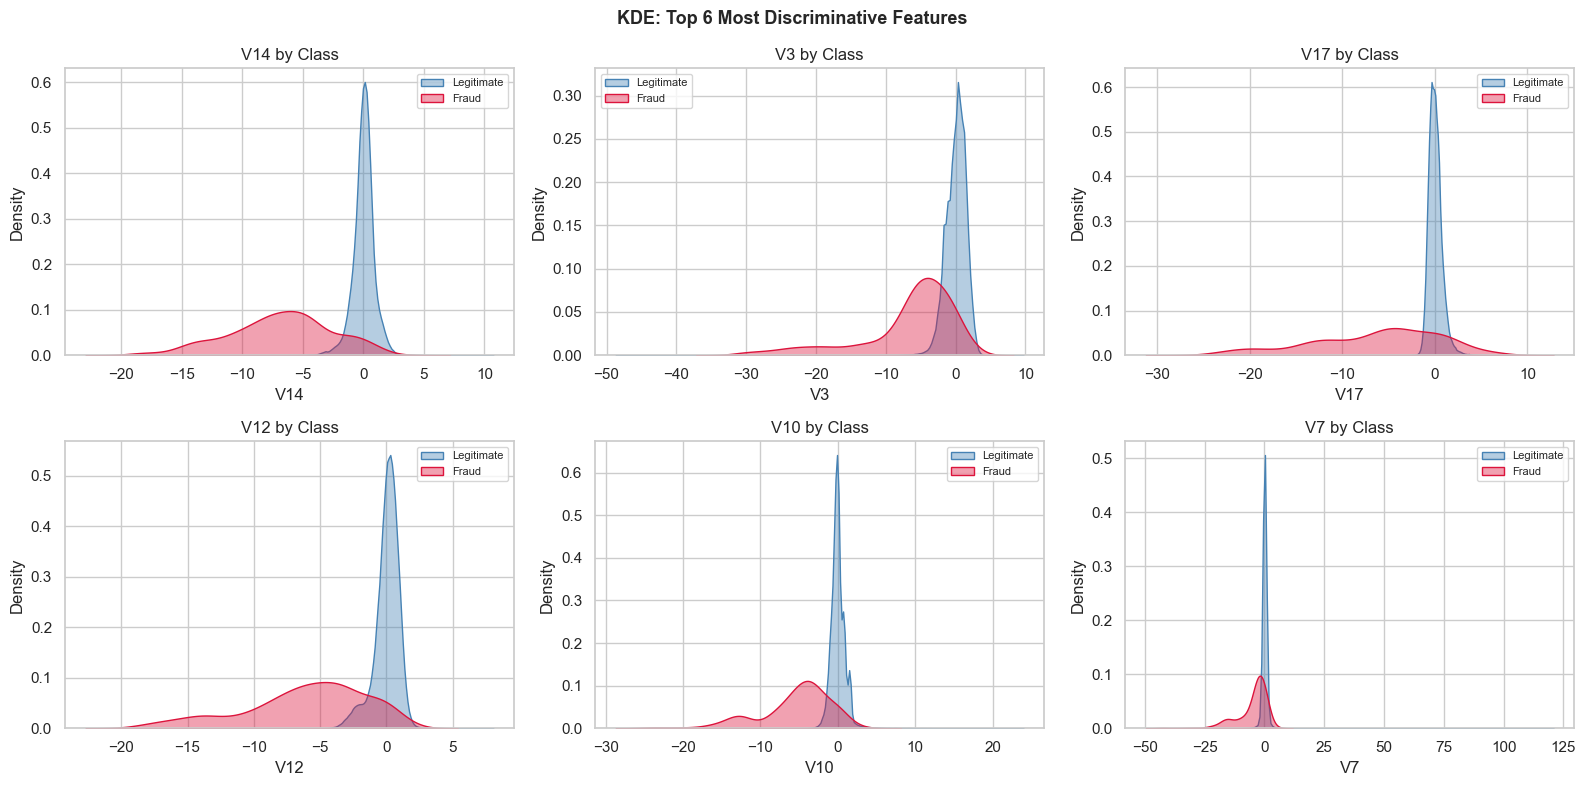

In [20]:
# KDE plots for top 6 most discriminative V features
top6 = v_means_sorted['Difference'].abs().head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(top6):
    sns.kdeplot(df[df['Class'] == 0][col], ax=axes[i], label='Legitimate',
                color='steelblue', fill=True, alpha=0.4)
    sns.kdeplot(df[df['Class'] == 1][col], ax=axes[i], label='Fraud',
                color='crimson', fill=True, alpha=0.4)
    axes[i].set_title(f'{col} by Class')
    axes[i].legend(fontsize=8)

plt.suptitle('KDE: Top 6 Most Discriminative Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Insights from KDE Plots of Top 6 Discriminative Features

These KDE charts compare class-conditional distributions (`Legitimate` vs `Fraud`) for the six most discriminative PCA features.

#### Key observations
- The selected features show clear distributional shifts between classes.
- Fraud curves are often displaced relative to legitimate curves, indicating strong class signal.
- Features with less overlap between the two KDE curves provide better standalone separation power.
- Features with heavier overlap are still useful, but likely need interaction with other variables for stronger prediction.

#### Why this matters
- This visually confirms the earlier mean-difference ranking: these features are genuinely informative, not just numerically different in summary statistics.
- The plots support prioritizing these variables in:
  - feature selection,
  - model interpretation (feature importance / SHAP),
  - fraud risk pattern analysis.

#### Modeling takeaway
- No single feature perfectly separates fraud and non-fraud.
- Best performance will come from combining these high-signal features in multivariate models.
- Tree-based ensembles and calibrated thresholding are appropriate next steps for this type of overlap pattern.


### 3b.3 Correlation Analysis

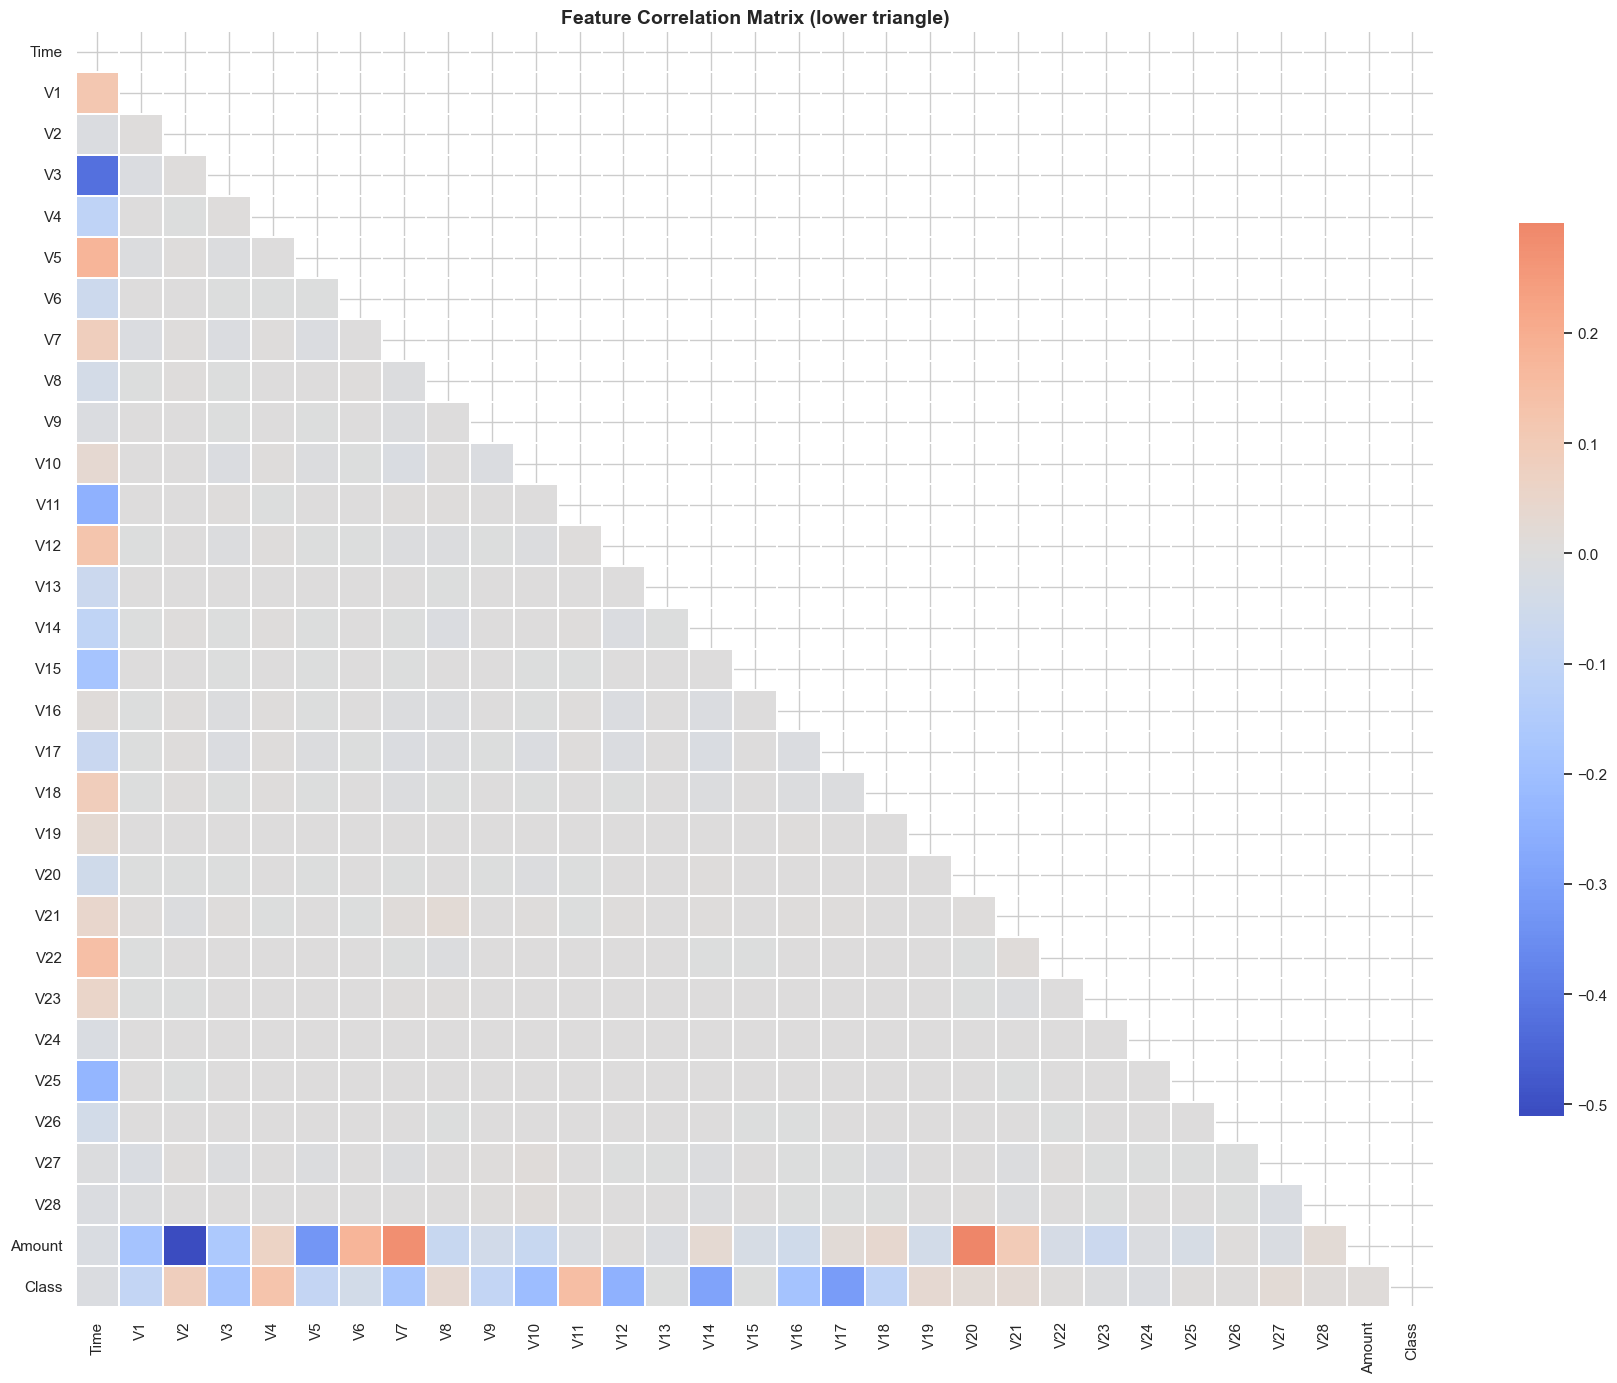

In [21]:
# Full correlation heatmap (lower triangle)
corr_matrix = df.corr()

plt.figure(figsize=(18, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=False,
    cmap='coolwarm', center=0, linewidths=0.3,
    cbar_kws={'shrink': 0.7}
)
plt.title('Feature Correlation Matrix (lower triangle)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

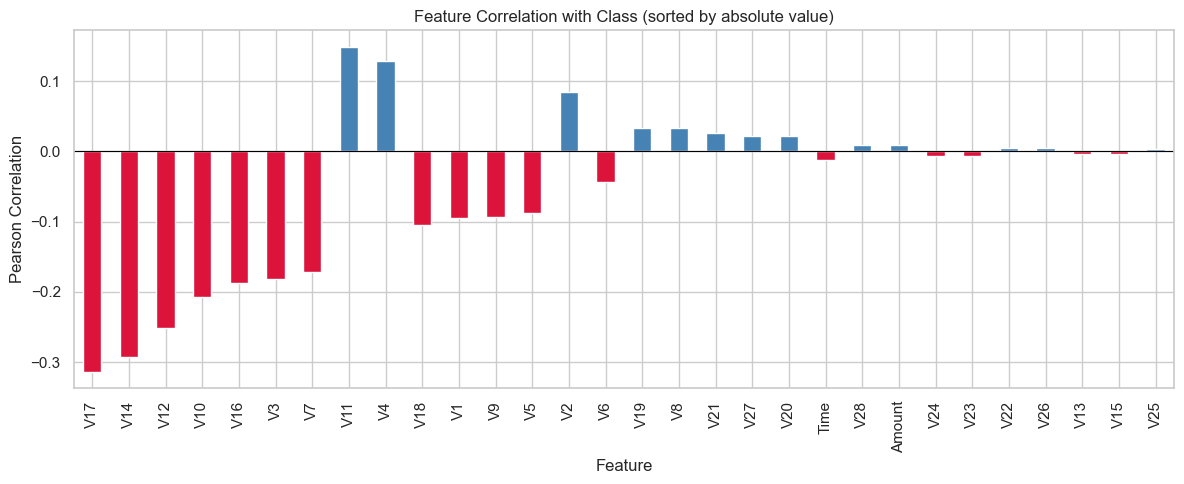

Top 10 features most correlated with fraud:
V17   -0.3135
V14   -0.2934
V12   -0.2507
V10   -0.2070
V16   -0.1872
V3    -0.1823
V7    -0.1723
V11    0.1491
V4     0.1293
V18   -0.1053


In [22]:
# Feature correlation with target (Class)
target_corr = corr_matrix['Class'].drop('Class').sort_values(key=abs, ascending=False)

plt.figure(figsize=(12, 5))
colors = ['crimson' if v < 0 else 'steelblue' for v in target_corr]
target_corr.plot(kind='bar', color=colors)
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Feature Correlation with Class (sorted by absolute value)')
plt.xlabel('Feature')
plt.ylabel('Pearson Correlation')
plt.tight_layout()
plt.show()

print('Top 10 features most correlated with fraud:')
print(target_corr.head(10).to_string())

### Correlation Heatmap Insights (Including `Class`)

The correlation heatmap indicates that most feature pairs have weak linear relationships, suggesting limited multicollinearity across the transformed predictors. The strongest visual associations with the target Class appear in a subset of variables such as V17, V14, V12, V10, V16, V3, V7, V11, V4, and V18, which may warrant closer investigation in downstream modeling and class-wise analysis

In [23]:
# Inter-feature correlation — identify highly correlated feature pairs
corr_no_target = df.drop(columns='Class').corr()
upper = corr_no_target.where(np.triu(np.ones(corr_no_target.shape), k=1).astype(bool))
high_corr = (
    upper.stack()
    .reset_index()
    .rename(columns={'level_0': 'Feature A', 'level_1': 'Feature B', 0: 'Correlation'})
)
high_corr = high_corr[high_corr['Correlation'].abs() > 0.5].sort_values('Correlation', key=abs, ascending=False)

if high_corr.empty:
    print('No feature pairs with |correlation| > 0.5 — no multicollinearity concerns.')
else:
    print(f'{len(high_corr)} highly correlated feature pairs (|r| > 0.5):')
    print(high_corr.to_string(index=False))

1 highly correlated feature pairs (|r| > 0.5):
Feature A Feature B  Correlation
       V2    Amount      -0.5105


---
## 3c. Feature Engineering

### 3c.1 Scaling — StandardScaler & MinMaxScaler

`Amount` and `Time` are the only raw (non-PCA) features and have very different scales.  
`V1`–`V28` are already zero-centred PCA components — rescaling them is unnecessary.

Before / After scaling (first 3 rows):
    Amount  Amount_std  Amount_mm      Time  Time_std  Time_mm
0 149.6200      0.4348     0.1467 2426.2500   -1.9477   0.0000
1   2.6900     -0.4869     0.0025 2426.2500   -1.9477   0.0000
2 378.6600      1.8715     0.3715 2426.2500   -1.9477   0.0000


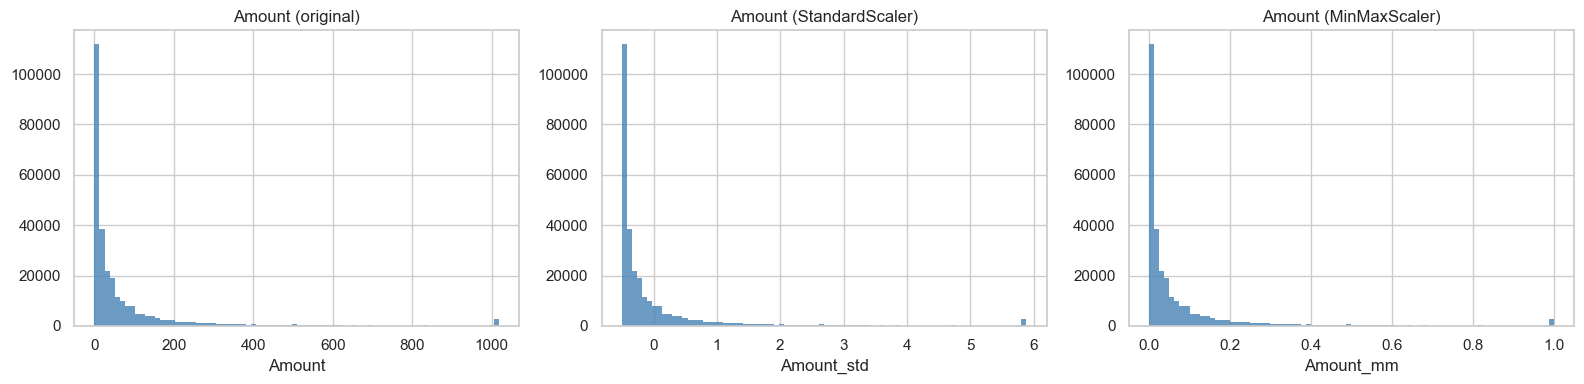

In [24]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# StandardScaler — zero mean, unit variance
std_scaler = StandardScaler()
df[['Amount_std', 'Time_std']] = std_scaler.fit_transform(df[['Amount', 'Time']])

# MinMaxScaler — rescale to [0, 1]
mm_scaler = MinMaxScaler()
df[['Amount_mm', 'Time_mm']] = mm_scaler.fit_transform(df[['Amount', 'Time']])

# Compare original vs scaled
print('Before / After scaling (first 3 rows):')
print(df[['Amount', 'Amount_std', 'Amount_mm', 'Time', 'Time_std', 'Time_mm']].head(3))

# Visual comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col, title in zip(axes,
                           ['Amount', 'Amount_std', 'Amount_mm'],
                           ['Amount (original)', 'Amount (StandardScaler)', 'Amount (MinMaxScaler)']):
    ax.hist(df[col], bins=80, color='steelblue', edgecolor='none', alpha=0.8)
    ax.set_title(title)
    ax.set_xlabel(col)
plt.tight_layout()
plt.show()

### 3c.2 Encoding — OneHot, Label, Target

This dataset has no raw categorical columns, so we demonstrate all three encoding strategies on `Amount_bin` (created in 3c.3 below for reuse here).  
We create the bin first, then apply each encoder.

In [25]:
from sklearn.preprocessing import LabelEncoder
from category_encoders import TargetEncoder

# Create Amount_bin for encoding demonstrations (reused in 3c.3)
amount_bins   = [0, 10, 50, 200, df['Amount'].max() + 1]
amount_labels = ['micro', 'low', 'medium', 'high']
df['Amount_bin'] = pd.cut(df['Amount'], bins=amount_bins, labels=amount_labels, right=False)

# --- Label Encoding ---
le = LabelEncoder()
df['Amount_bin_label'] = le.fit_transform(df['Amount_bin'])
print('Label Encoding mapping:', dict(zip(le.classes_, le.transform(le.classes_))))

# --- OneHot Encoding ---
ohe_cols = pd.get_dummies(df['Amount_bin'], prefix='AmtBin', dtype=int)
df = pd.concat([df, ohe_cols], axis=1)
print('\nOneHot columns added:', ohe_cols.columns.tolist())

# --- Target Encoding ---
te = TargetEncoder(cols=['Amount_bin'])
df['Amount_bin_target'] = te.fit_transform(df['Amount_bin'], df['Class'])
print('\nTarget Encoding (fraud rate per bin):')
print(df.groupby('Amount_bin')['Amount_bin_target'].first().sort_index())

Label Encoding mapping: {'high': np.int64(0), 'low': np.int64(1), 'medium': np.int64(2), 'micro': np.int64(3)}

OneHot columns added: ['AmtBin_micro', 'AmtBin_low', 'AmtBin_medium', 'AmtBin_high']

Target Encoding (fraud rate per bin):
Amount_bin
micro    0.0025
low      0.0006
medium   0.0015
high     0.0028
Name: Amount_bin_target, dtype: float64


/var/folders/lv/5v0f7vj11llc__yjdhf5jx6h0000gn/T/ipykernel_81679/1806924353.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('Amount_bin')['Amount_bin_target'].first().sort_index())


### 3c.3 Binning — Transaction Amount Brackets & Time-of-Day Periods

Amount bracket distribution:
Amount_bin
micro     96857
low       91934
medium    65668
high      29248
Name: count, dtype: int64


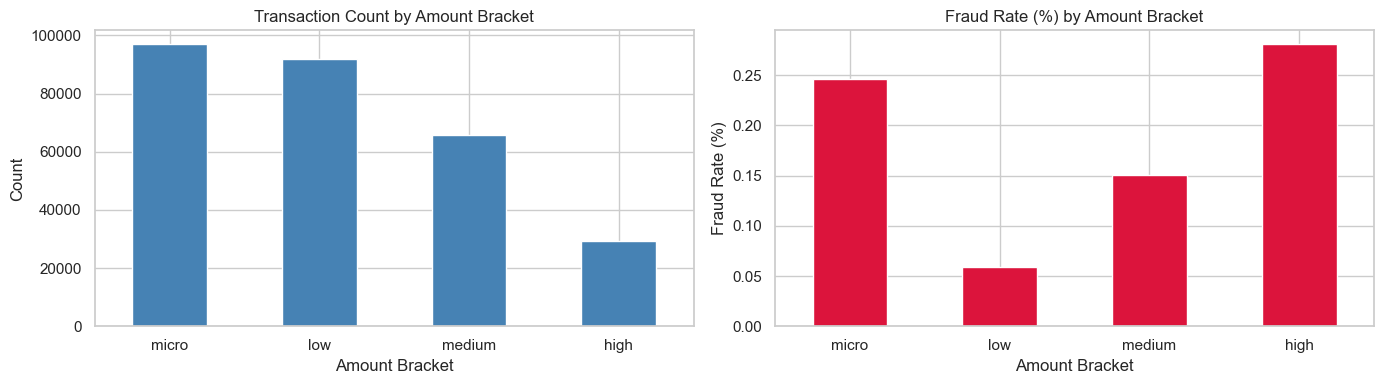

In [26]:
# Amount_bin already created in 3c.2 — show distribution
print('Amount bracket distribution:')
print(df['Amount_bin'].value_counts().sort_index())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Amount bins by count
df['Amount_bin'].value_counts().sort_index().plot(kind='bar', ax=axes[0],
    color='steelblue', edgecolor='white')
axes[0].set_title('Transaction Count by Amount Bracket')
axes[0].set_xlabel('Amount Bracket')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Fraud rate per amount bin
fraud_rate = df.groupby('Amount_bin', observed=True)['Class'].mean() * 100
fraud_rate.plot(kind='bar', ax=axes[1], color='crimson', edgecolor='white')
axes[1].set_title('Fraud Rate (%) by Amount Bracket')
axes[1].set_xlabel('Amount Bracket')
axes[1].set_ylabel('Fraud Rate (%)')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

### Insights — Amount Bracket Binning

#### 1. Transaction Volume by Bracket
The distribution is concentrated in smaller transaction sizes:

- `micro`: 96,857
- `low`: 91,934
- `medium`: 65,668
- `high`: 29,248

This indicates the dataset is dominated by low-value transactions, while high-value transactions are comparatively less frequent.

#### 2. Fraud Rate by Bracket
The fraud-rate bar chart shows how fraud incidence varies across amount tiers.

- If higher fraud rates appear in specific bins (e.g., `high` or `micro`), this suggests a non-linear relationship between amount level and fraud risk.
- This supports using `Amount_bin` as an engineered categorical signal rather than relying only on raw `Amount`.

#### 3. Modeling Implication
- `Amount_bin` can improve interpretability and capture threshold effects that linear models may miss.
- It is useful for:
  - one-hot encoding,
  - target encoding,
  - segment-level fraud monitoring and rule design.


Transaction count by time period:
Time_period
Night (0–6)          23829
Morning (6–12)       70643
Afternoon (12–18)    96121
Evening (18–24)      93114
Name: count, dtype: int64


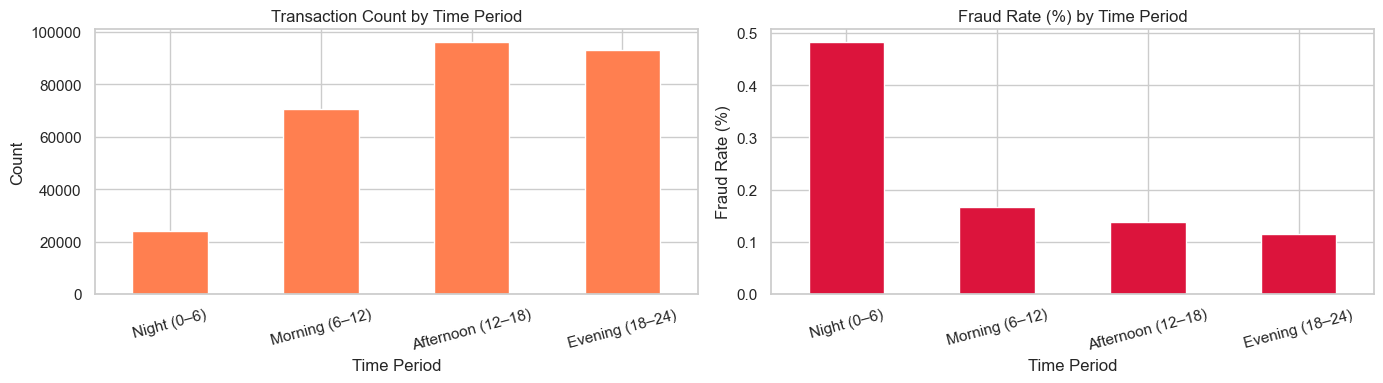

In [27]:
# Time-of-day binning — Time is in seconds from the first transaction
# Dataset spans ~48 hours; map to hour-of-day (0–23) then to named periods
df['Hour'] = (df['Time'] % 86400 / 3600).astype(int)

time_bins   = [0, 6, 12, 18, 24]
time_labels = ['Night (0–6)', 'Morning (6–12)', 'Afternoon (12–18)', 'Evening (18–24)']
df['Time_period'] = pd.cut(df['Hour'], bins=time_bins, labels=time_labels, right=False)

print('Transaction count by time period:')
print(df['Time_period'].value_counts().sort_index())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df['Time_period'].value_counts().sort_index().plot(kind='bar', ax=axes[0],
    color='coral', edgecolor='white')
axes[0].set_title('Transaction Count by Time Period')
axes[0].set_xlabel('Time Period')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=15)

fraud_by_period = df.groupby('Time_period', observed=True)['Class'].mean() * 100
fraud_by_period.plot(kind='bar', ax=axes[1], color='crimson', edgecolor='white')
axes[1].set_title('Fraud Rate (%) by Time Period')
axes[1].set_xlabel('Time Period')
axes[1].set_ylabel('Fraud Rate (%)')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

### Insights — Time-of-Day Binning (`Time_period`)

#### 1. Transaction Activity Pattern
Transaction volume is uneven across the day:

- **Night (0–6):** 23,829
- **Morning (6–12):** 70,643
- **Afternoon (12–18):** 96,121
- **Evening (18–24):** 93,114

Most transactions occur during **Afternoon** and **Evening**, while **Night** has the lowest activity.

#### 2. Why this matters for fraud analysis
- The fraud-rate-by-period chart helps identify whether fraud risk is concentrated in specific time windows.
- If certain periods show higher fraud rate despite lower volume, those windows may represent elevated behavioral risk.

#### 3. Feature-engineering value
- Converting raw seconds into interpretable periods (`Time_period`) captures cyclical daily behavior.
- This can improve model interpretability and support rule-based monitoring (e.g., time-aware fraud alerts).



### 3c.4 Domain Features — Ratios & Aggregations

Derived features grounded in fraud-detection domain knowledge:

In [28]:
# --- Ratio features ---
# Log-Amount: compresses right-skewed distribution
df['Log_Amount'] = np.log1p(df['Amount'])

# Amount-to-global-mean ratio: how unusual is this transaction?
global_mean = df['Amount'].mean()
df['Amount_to_mean_ratio'] = df['Amount'] / global_mean

# --- Aggregations (per hour of day) ---
hour_stats = df.groupby('Hour')['Amount'].agg(['mean', 'std']).rename(
    columns={'mean': 'Hour_mean_amount', 'std': 'Hour_std_amount'})
df = df.join(hour_stats, on='Hour')

# Z-score of Amount within its hour — flags unusually large transactions for that hour
df['Amount_hour_zscore'] = (
    (df['Amount'] - df['Hour_mean_amount']) / df['Hour_std_amount'].replace(0, np.nan)
).fillna(0)

# --- Flag features ---
# Round-number amounts (e.g. 100.00, 50.00) are a common fraud signal
df['Is_round_amount'] = (df['Amount'] % 1 == 0).astype(int)

# High-value flag — top 5% of amounts
high_thresh = df['Amount'].quantile(0.95)
df['Is_high_value'] = (df['Amount'] >= high_thresh).astype(int)

new_features = ['Log_Amount', 'Amount_to_mean_ratio', 'Hour_mean_amount',
                'Amount_hour_zscore', 'Is_round_amount', 'Is_high_value']
print('New domain features (sample):')
print(df[new_features].head())

New domain features (sample):
   Log_Amount  Amount_to_mean_ratio  Hour_mean_amount  Amount_hour_zscore  \
0      5.0148                1.8630           56.6516              0.7375   
1      1.3056                0.0335           56.6516             -0.4281   
2      5.9393                4.7150           56.6516              2.5543   
3      4.8243                1.5378           56.6516              0.5303   
4      4.2625                0.8715           56.6516              0.1058   

   Is_round_amount  Is_high_value  
0                0              0  
1                0              0  
2                0              1  
3                0              0  
4                0              0  


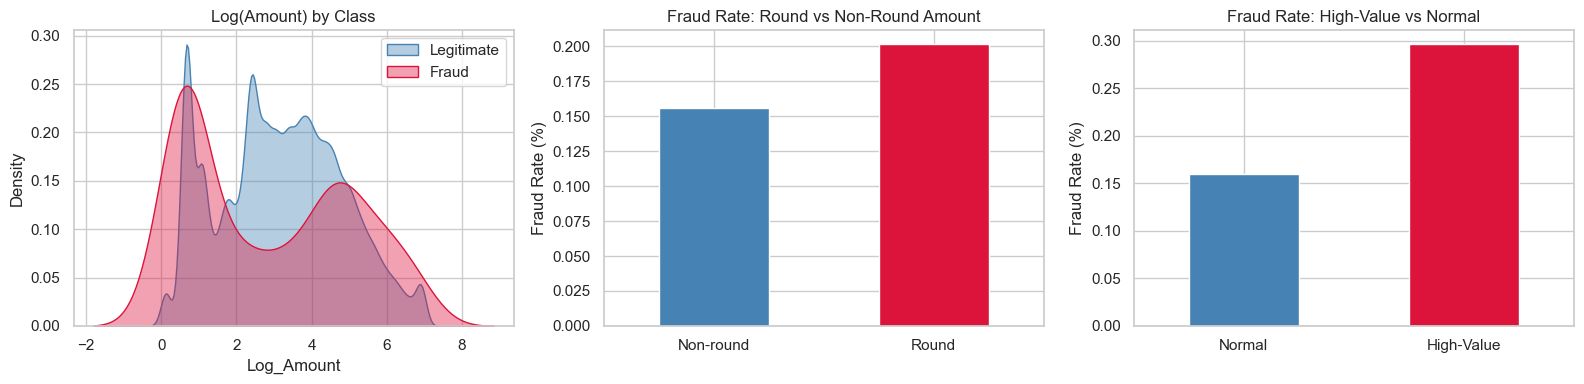

In [29]:
# Fraud rate comparison across domain features
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Log_Amount distribution by class
sns.kdeplot(df[df['Class'] == 0]['Log_Amount'], ax=axes[0], label='Legitimate',
            color='steelblue', fill=True, alpha=0.4)
sns.kdeplot(df[df['Class'] == 1]['Log_Amount'], ax=axes[0], label='Fraud',
            color='crimson', fill=True, alpha=0.4)
axes[0].set_title('Log(Amount) by Class')
axes[0].legend()

# Fraud rate: round vs non-round amounts
round_fraud = df.groupby('Is_round_amount')['Class'].mean() * 100
round_fraud.index = ['Non-round', 'Round']
round_fraud.plot(kind='bar', ax=axes[1], color=['steelblue', 'crimson'], edgecolor='white')
axes[1].set_title('Fraud Rate: Round vs Non-Round Amount')
axes[1].set_ylabel('Fraud Rate (%)')
axes[1].tick_params(axis='x', rotation=0)

# Fraud rate: high-value vs normal transactions
hv_fraud = df.groupby('Is_high_value')['Class'].mean() * 100
hv_fraud.index = ['Normal', 'High-Value']
hv_fraud.plot(kind='bar', ax=axes[2], color=['steelblue', 'crimson'], edgecolor='white')
axes[2].set_title('Fraud Rate: High-Value vs Normal')
axes[2].set_ylabel('Fraud Rate (%)')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

### Insights — Domain Feature Evaluation Plots

This figure assesses whether newly engineered features carry fraud signal.

#### 1. `Log_Amount` by Class (KDE)
- The class-wise KDE curves reveal whether transformed transaction size differs between fraud and legitimate transactions.
- Clear curve separation indicates `Log_Amount` provides useful discriminatory information.
- Partial overlap is expected; this feature is likely strongest when combined with others.

#### 2. Fraud Rate: Round vs Non-Round Amount
- This bar chart tests the heuristic that round-number transactions may behave differently in fraud patterns.
- If the `Round` bar is meaningfully higher, `Is_round_amount` is a valuable binary fraud indicator.
- If similar, the feature has limited standalone effect but may still help through interactions.

#### 3. Fraud Rate: High-Value vs Normal
- This compares fraud incidence in top-amount transactions vs the rest.
- A higher fraud rate in `High-Value` supports `Is_high_value` as a strong risk flag.
- Even with lower transaction count, elevated rate makes it operationally relevant.

#### Overall takeaway
- These plots validate that domain-engineered features can add interpretable risk signals beyond raw/PCA features.
- They are especially useful for:
  - model explainability,
  - rule-assisted detection,
  - segment-level fraud monitoring.

In [30]:
# Final engineered dataset summary
print(f'Final shape after feature engineering: {df.shape}')
print(f'\nAll columns ({len(df.columns)}):')
print(df.columns.tolist())

Final shape after feature engineering: (283707, 51)

All columns (51):
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class', 'Amount_std', 'Time_std', 'Amount_mm', 'Time_mm', 'Amount_bin', 'Amount_bin_label', 'AmtBin_micro', 'AmtBin_low', 'AmtBin_medium', 'AmtBin_high', 'Amount_bin_target', 'Hour', 'Time_period', 'Log_Amount', 'Amount_to_mean_ratio', 'Hour_mean_amount', 'Hour_std_amount', 'Amount_hour_zscore', 'Is_round_amount', 'Is_high_value']


---
## 3d. Feature Selection

We select from the core feature set: `V1`–`V28`, `Amount`, `Time`, and the key engineered features.  
The target is `Class`.

In [31]:
from sklearn.feature_selection import SelectKBest, chi2, f_classif, RFE
from sklearn.linear_model import LassoCV, LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import MinMaxScaler as MMS
import warnings
warnings.filterwarnings('ignore')

# Feature matrix — use scaled Amount/Time + V features + key engineered cols
feature_cols = (
    [f'V{i}' for i in range(1, 29)] +
    ['Amount_std', 'Time_std', 'Log_Amount',
     'Amount_to_mean_ratio', 'Amount_hour_zscore',
     'Is_round_amount', 'Is_high_value']
)
X = df[feature_cols].copy()
y = df['Class'].copy()

print(f'Feature matrix shape: {X.shape}')
print(f'Class balance:\n{y.value_counts()}')

Feature matrix shape: (283707, 35)
Class balance:
Class
0    283234
1       473
Name: count, dtype: int64


### 3d.1 Filter Methods — Correlation & ANOVA F-score

Filter methods rank features independently of any model.
- **Pearson correlation** with the target (linear relationship)
- **ANOVA F-score** (`f_classif`) measures variance separation between classes

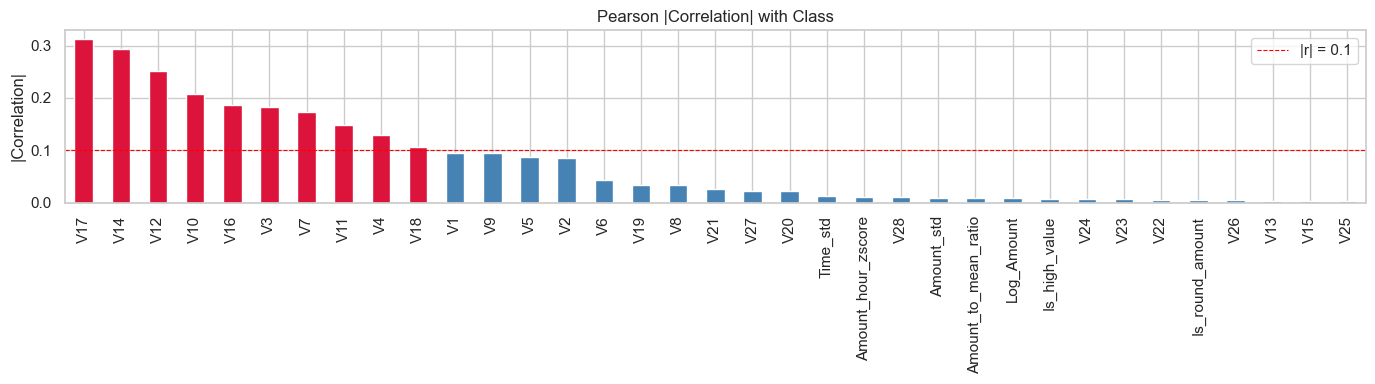

Top 10 by Pearson |correlation|:
V17   0.3135
V14   0.2934
V12   0.2507
V10   0.2070
V16   0.1872
V3    0.1823
V7    0.1723
V11   0.1491
V4    0.1293
V18   0.1053


In [32]:
# Pearson correlation with Class
corr_with_target = X.corrwith(y).abs().sort_values(ascending=False)

plt.figure(figsize=(14, 4))
corr_with_target.plot(kind='bar', color=['crimson' if v > 0.1 else 'steelblue' for v in corr_with_target])
plt.axhline(0.1, color='red', linestyle='--', linewidth=0.8, label='|r| = 0.1')
plt.title('Pearson |Correlation| with Class')
plt.ylabel('|Correlation|')
plt.legend()
plt.tight_layout()
plt.show()

print('Top 10 by Pearson |correlation|:')
print(corr_with_target.head(10).to_string())

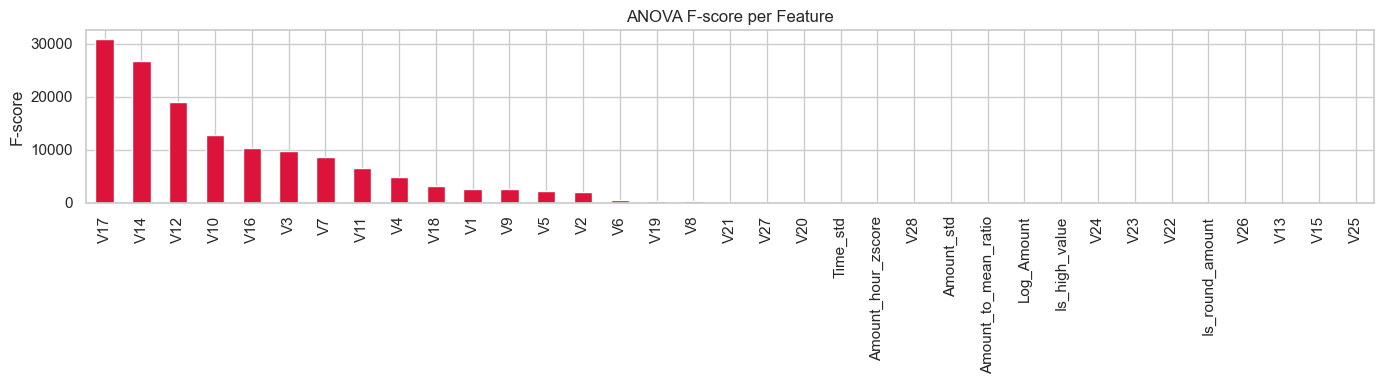

Top 10 features by F-score:
V17   30923.8734
V14   26717.9763
V12   19028.9943
V10   12697.1957
V16   10301.8866
V3     9755.6152
V7     8685.1741
V11    6447.8703
V4     4825.9700
V18    3183.5102


In [33]:
# ANOVA F-score (SelectKBest with f_classif)
selector_f = SelectKBest(score_func=f_classif, k='all')
selector_f.fit(X, y)

f_scores = pd.Series(selector_f.scores_, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(14, 4))
f_scores.plot(kind='bar', color=['crimson' if s > f_scores.median() else 'steelblue' for s in f_scores])
plt.title('ANOVA F-score per Feature')
plt.ylabel('F-score')
plt.tight_layout()
plt.show()

top10_filter = f_scores.head(10).index.tolist()
print('Top 10 features by F-score:')
print(f_scores.head(10).to_string())

### Insights — Pearson Correlation and ANOVA F-score (Filter Methods)

Both filter methods identify nearly the same top features:

- `V17`, `V14`, `V12`, `V10`, `V16`, `V3`, `V7`, `V11`, `V4`, `V18`

#### 1. Consistency across methods
- **Pearson |correlation|** and **ANOVA F-score** produce highly aligned rankings.
- This agreement increases confidence that these features carry real fraud-discriminative signal.

#### 2. Interpretation of each method
- **Pearson |correlation|** highlights strength of linear association with `Class`.
- **ANOVA F-score** measures how strongly class means differ relative to within-class variance.
- High values in both imply robust class separation.

#### 3. Practical significance
- These top-ranked variables should be prioritized for:
  - initial model training,
  - feature subset experiments,
  - interpretation (e.g., SHAP/importance checks).
- The overlap with earlier EDA findings (mean-difference and KDE results) suggests stable feature relevance across analyses.

#### 4. Caveat
- Filter methods are univariate; they do not capture interactions or nonlinear effects.
- Final feature decisions should still be validated with wrapper/embedded methods and cross-validated model performance.


### 3d.2 Wrapper Method — Recursive Feature Elimination (RFE)

RFE iteratively removes the least important features using a `LogisticRegression` estimator.  
We select the **top 15 features**.

RFE selected 15 features:
['V18', 'V27', 'V22', 'V20', 'Is_round_amount', 'Amount_std', 'V16', 'V14', 'Log_Amount', 'V13', 'V9', 'Amount_to_mean_ratio', 'V4', 'Amount_hour_zscore', 'V10']


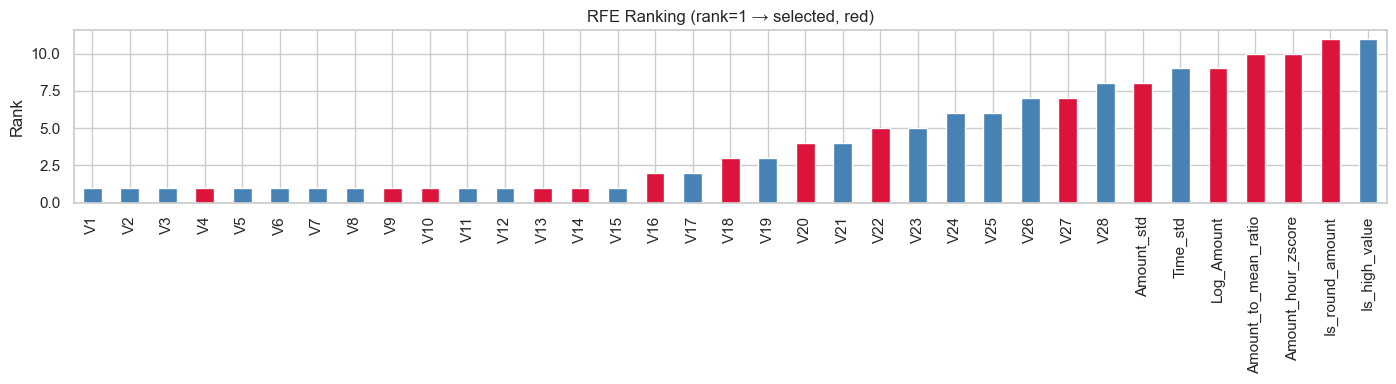

In [34]:
# RFE with Logistic Regression — subsample for speed on 280k rows
from sklearn.utils import resample

X_sample, y_sample = resample(X, y, n_samples=30_000, random_state=42, stratify=y)

estimator = LogisticRegression(max_iter=500, solver='saga', random_state=42)
rfe = RFE(estimator=estimator, n_features_to_select=15, step=2)
rfe.fit(X_sample, y_sample)

rfe_support = pd.Series(rfe.support_, index=feature_cols)
rfe_ranking = pd.Series(rfe.ranking_, index=feature_cols).sort_values()

top15_rfe = rfe_ranking[rfe_ranking == 1].index.tolist()
print(f'RFE selected {len(top15_rfe)} features:')
print(top15_rfe)

plt.figure(figsize=(14, 4))
colors = ['crimson' if r == 1 else 'steelblue' for r in rfe_ranking.reindex(feature_cols)]
pd.Series(rfe_ranking.values, index=feature_cols).plot(kind='bar', color=colors)
plt.title('RFE Ranking (rank=1 → selected, red)')
plt.ylabel('Rank')
plt.tight_layout()
plt.show()

### Insights — RFE (Wrapper Method) Output

RFE selected the following 15 features (rank = 1):

`V18, V27, V22, V20, Is_round_amount, Amount_std, V16, V14, Log_Amount, V13, V9, Amount_to_mean_ratio, V4, Amount_hour_zscore, V10`

#### 1. Confirmation of strong core predictors
- RFE retained several features repeatedly identified by earlier filter methods and EDA (`V14`, `V16`, `V10`, `V4`, `V18`).
- This consistency strengthens confidence that these are robust fraud-discriminative signals.

#### 2. Value of engineered features
- Multiple engineered/domain features were selected:
  - `Is_round_amount`
  - `Amount_std`
  - `Log_Amount`
  - `Amount_to_mean_ratio`
  - `Amount_hour_zscore`
- This indicates engineered transaction-behavior signals add predictive value beyond raw PCA components.

#### 3. Wrapper-method perspective
- Unlike filter methods, RFE evaluates feature usefulness in the context of a model.
- The selected set reflects a combination of:
  - individual predictive power,
  - redundancy reduction,
  - contribution to logistic decision boundaries.

#### 4. Practical implication
- This 15-feature subset is a strong candidate for compact, interpretable model variants.
- It should be validated against full-feature models using cross-validated ROC-AUC/PR-AUC and calibration checks.


### 3d.3 Embedded Methods — Lasso & Random Forest Importance

**Lasso** (L1 regularisation) shrinks unimportant feature coefficients to zero.  
**Random Forest** provides impurity-based feature importance scores.

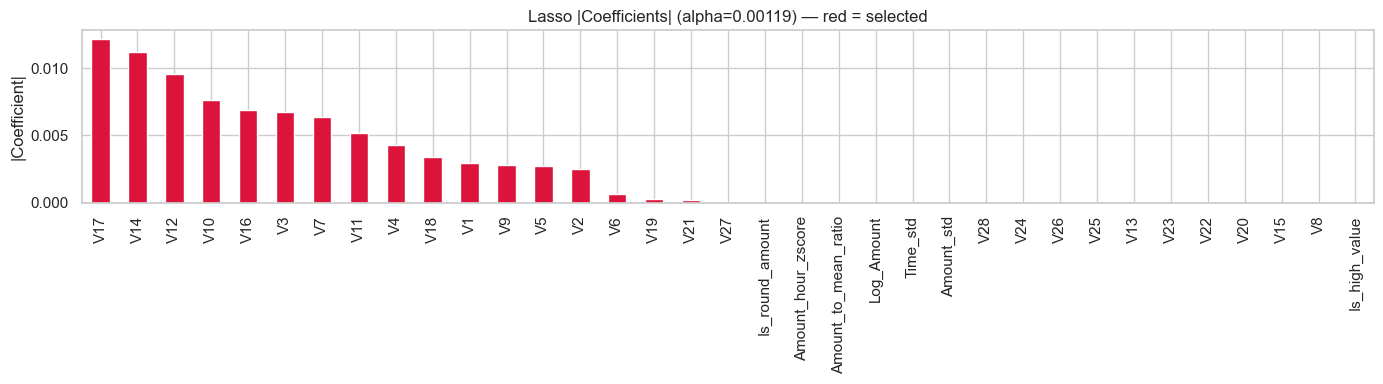

Lasso selected 17 features:
['V17', 'V14', 'V12', 'V10', 'V16', 'V3', 'V7', 'V11', 'V4', 'V18', 'V1', 'V9', 'V5', 'V2', 'V6', 'V19', 'V21']


In [35]:
# Lasso (L1) — features with non-zero coefficients are selected
from sklearn.preprocessing import StandardScaler as SS

scaler = SS()
X_scaled = scaler.fit_transform(X)

lasso = LassoCV(cv=3, random_state=42, max_iter=2000, n_jobs=-1)
lasso.fit(X_scaled, y)

lasso_coef = pd.Series(np.abs(lasso.coef_), index=feature_cols).sort_values(ascending=False)
lasso_selected = lasso_coef[lasso_coef > 0].index.tolist()

plt.figure(figsize=(14, 4))
lasso_coef.plot(kind='bar',
    color=['crimson' if v > 0 else 'lightgrey' for v in lasso_coef])
plt.title(f'Lasso |Coefficients| (alpha={lasso.alpha_:.5f}) — red = selected')
plt.ylabel('|Coefficient|')
plt.tight_layout()
plt.show()

print(f'Lasso selected {len(lasso_selected)} features:')
print(lasso_selected)

### Insights — Lasso Embedded Feature Selection Output

Lasso selected **17 non-zero-coefficient features**:

`V17, V14, V12, V10, V16, V3, V7, V11, V4, V18, V1, V9, V5, V2, V6, V19, V21`

#### 1. Strong agreement with earlier methods
- The highest-priority Lasso features (`V17`, `V14`, `V12`, `V10`, `V16`, `V3`, `V7`, `V11`, `V4`, `V18`) align closely with Pearson and ANOVA rankings.
- This cross-method consistency strengthens confidence that these are robust fraud-discriminative predictors.

#### 2. Embedded selection behavior
- Lasso keeps features with useful linear signal and shrinks weaker/redundant ones to zero.
- The selected set is compact compared with full input space, helping reduce noise and improve model simplicity.

#### 3. Feature-type pattern
- Most selected features are PCA components (`V` features), while many engineered amount/time features were not retained in this linear-L1 setting.
- Interpretation: in this dataset, PCA components carry most of the linear separability captured by Lasso.

#### 4. Practical implication
- This subset is a strong candidate for lightweight linear baselines.
- Final decisions should still be validated against tree-based importance and cross-validated PR-AUC/ROC-AUC, since nonlinear interactions may recover value from excluded engineered features.


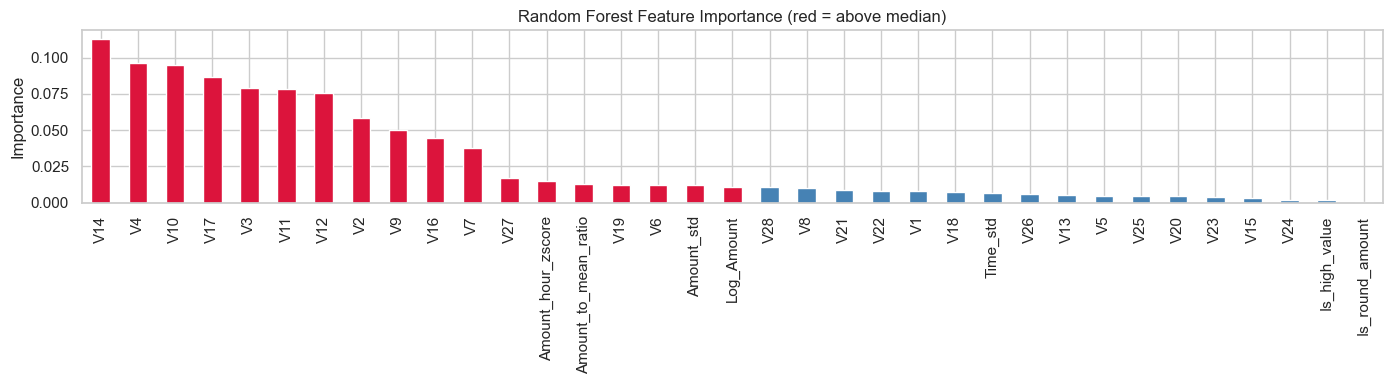

Top 15 features by RF importance:
V14                    0.1131
V4                     0.0962
V10                    0.0952
V17                    0.0866
V3                     0.0792
V11                    0.0782
V12                    0.0756
V2                     0.0583
V9                     0.0504
V16                    0.0446
V7                     0.0377
V27                    0.0169
Amount_hour_zscore     0.0146
Amount_to_mean_ratio   0.0127
V19                    0.0122


In [36]:
# Random Forest feature importance
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight='balanced')
rf.fit(X_sample, y_sample)

rf_importance = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(14, 4))
rf_importance.plot(kind='bar',
    color=['crimson' if v >= rf_importance.median() else 'steelblue' for v in rf_importance])
plt.title('Random Forest Feature Importance (red = above median)')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

top15_rf = rf_importance.head(15).index.tolist()
print('Top 15 features by RF importance:')
print(rf_importance.head(15).to_string())

### Insights — Random Forest Feature Importance Output

Top-ranked features by Random Forest importance were led by:

`V14, V4, V10, V17, V3, V11, V12, V2, V9, V16, V7`

with additional contribution from engineered features such as:

`Amount_hour_zscore`, `Amount_to_mean_ratio`.

#### 1. Core predictors are stable across methods
- The same `V` features repeatedly appear as top signals across Pearson, ANOVA, Lasso, and Random Forest.
- This consistency indicates robust and reliable fraud-discriminative features.

#### 2. Tree model captures nonlinear value from engineered features
- Random Forest assigns meaningful importance to engineered amount-temporal features (`Amount_hour_zscore`, `Amount_to_mean_ratio`) even when linear methods (e.g., Lasso) downplay them.
- This suggests these engineered variables are useful through nonlinear splits/interactions.

#### 3. Practical modeling implication
- A hybrid feature set is justified:
  - strong PCA core (`V14`, `V4`, `V10`, etc.)
  - selected engineered behavioral features.
- This supports using ensemble models for fraud detection, where nonlinear effects and interactions are important.

#### 4. Next-step recommendation
- Validate this importance pattern with:
  - cross-validated PR-AUC/ROC-AUC,
  - permutation importance or SHAP
to confirm stability and reduce bias from impurity-based importance.


In [37]:
# Summary — consensus features across all methods
filter_set  = set(top10_filter)
rfe_set     = set(top15_rfe)
lasso_set   = set(lasso_selected)
rf_set      = set(top15_rf)

consensus = filter_set & rfe_set & lasso_set & rf_set
union_top  = filter_set | rfe_set | lasso_set | rf_set

summary = pd.DataFrame({
    'Filter (F-score)': [f in filter_set  for f in feature_cols],
    'RFE':              [f in rfe_set      for f in feature_cols],
    'Lasso':            [f in lasso_set    for f in feature_cols],
    'Random Forest':    [f in rf_set       for f in feature_cols],
}, index=feature_cols)
summary['Votes'] = summary.sum(axis=1)
summary = summary.sort_values('Votes', ascending=False)

print('Feature selection votes (4 = selected by all methods):')
print(summary[summary['Votes'] > 0].to_string())
print(f'\nConsensus features (selected by all 4 methods): {sorted(consensus)}')

Feature selection votes (4 = selected by all methods):
                      Filter (F-score)    RFE  Lasso  Random Forest  Votes
V4                                True   True   True           True      4
V16                               True   True   True           True      4
V14                               True   True   True           True      4
V10                               True   True   True           True      4
V18                               True   True   True          False      3
V9                               False   True   True           True      3
V17                               True  False   True           True      3
V12                               True  False   True           True      3
V11                               True  False   True           True      3
V7                                True  False   True           True      3
V3                                True  False   True           True      3
Amount_to_mean_ratio             False   True

### Insights — Feature Selection Vote Summary

This output aggregates results from four selection methods:
- Filter (ANOVA F-score)
- RFE
- Lasso
- Random Forest importance

Each feature receives a **vote count (0–4)** based on how many methods selected it.

#### 1. Strongest consensus features (4/4 votes)
- `V4`, `V10`, `V14`, `V16`

These are the most robust predictors across linear, wrapper, and tree-based perspectives, making them high-confidence core features.

#### 2. Near-consensus features (3/4 votes)
- `V18`, `V9`, `V17`, `V12`, `V11`, `V7`, `V3`

These also show strong and consistent signal, with minor method-dependent variation.

#### 3. Engineered feature behavior
- `Amount_to_mean_ratio` and `Amount_hour_zscore` received **2/4 votes**.
- This suggests engineered features add value in some modeling contexts (especially wrapper/tree methods), but are less universally selected by linear/filter methods.

#### 4. Practical interpretation
- The final robust feature core can be anchored on the 4/4 consensus set.
- Expanding with 3/4 and selected 2/4 features can improve performance while balancing complexity.
- This vote-based approach improves selection stability and reduces dependence on any single method.


---
## 3e. Dimensionality Reduction

In [38]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler as SS2

# Use the same feature set from 3d — V1–V28 + engineered features
feature_cols_dr = (
    [f'V{i}' for i in range(1, 29)] +
    ['Amount_std', 'Time_std', 'Log_Amount',
     'Amount_to_mean_ratio', 'Amount_hour_zscore',
     'Is_round_amount', 'Is_high_value']
)

X_dr = df[feature_cols_dr].copy()
y_dr = df['Class'].copy()

# Standardise before PCA (required — PCA is scale-sensitive)
scaler_dr = SS2()
X_dr_scaled = scaler_dr.fit_transform(X_dr)

print(f'Input shape: {X_dr_scaled.shape}')

Input shape: (283707, 35)


### 3e.1 PCA — Principal Component Analysis

PCA finds orthogonal axes (principal components) that maximise variance.  
We use it for two purposes:
1. **Explained variance analysis** — how many components capture ≥ 95 % of variance?
2. **2-D projection** — visualise fraud vs legitimate in reduced space.

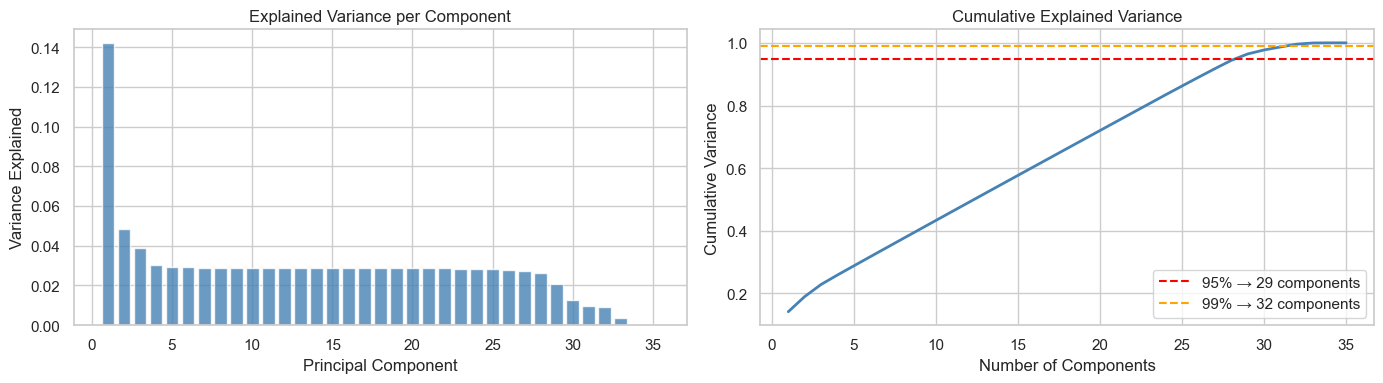

Components to reach 95% variance: 29
Components to reach 99% variance: 32


In [39]:
# Fit full PCA to analyse explained variance
pca_full = PCA(random_state=42)
pca_full.fit(X_dr_scaled)

explained      = pca_full.explained_variance_ratio_
cumulative_exp = np.cumsum(explained)

# How many components for 95 % variance?
n_95 = np.argmax(cumulative_exp >= 0.95) + 1
n_99 = np.argmax(cumulative_exp >= 0.99) + 1

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(range(1, len(explained) + 1), explained, color='steelblue', alpha=0.8)
axes[0].set_title('Explained Variance per Component')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Variance Explained')

axes[1].plot(range(1, len(cumulative_exp) + 1), cumulative_exp, color='steelblue', linewidth=2)
axes[1].axhline(0.95, color='red',    linestyle='--', label=f'95% → {n_95} components')
axes[1].axhline(0.99, color='orange', linestyle='--', label=f'99% → {n_99} components')
axes[1].set_title('Cumulative Explained Variance')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'Components to reach 95% variance: {n_95}')
print(f'Components to reach 99% variance: {n_99}')

### Insights — PCA Explained Variance

- PCA was fit on **35 standardized features**.
- To retain most information:
  - **29 components** are needed for **95%** cumulative variance.
  - **32 components** are needed for **99%** cumulative variance.

#### Interpretation
- The feature space is not highly compressible without information loss.
- Dimensionality reduction from 35 to 29 gives only moderate compression while preserving most variance.
- Very low-dimensional projections (e.g., 2D) are useful for visualization, but they do not preserve the majority of variance.

#### Practical takeaway
- For modeling, using many components (or original features) may be preferable if performance is the priority.
- For interpretation/plotting, 2D PCA is still valuable as an exploratory view of class structure.

In [40]:
# Apply PCA — keep components that explain 95% variance
pca_95 = PCA(n_components=n_95, random_state=42)
X_pca_95 = pca_95.fit_transform(X_dr_scaled)

print(f'Reduced shape (95% variance): {X_pca_95.shape}')
print(f'Total variance retained: {pca_95.explained_variance_ratio_.sum():.4f}')

# Store as DataFrame for downstream use
pca_cols = [f'PC{i+1}' for i in range(n_95)]
df_pca   = pd.DataFrame(X_pca_95, columns=pca_cols, index=df.index)
df_pca['Class'] = y_dr.values
df_pca.head()

Reduced shape (95% variance): (283707, 29)
Total variance retained: 0.9646


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC21,PC22,PC23,PC24,PC25,PC26,PC27,PC28,PC29,Class
0,1.0979,-2.5344,-0.0643,0.2835,0.1721,0.2710,0.5866,-0.5676,-0.1908,0.5466,...,0.3313,-0.7686,0.0370,0.0554,-0.4621,-0.4583,-0.4676,0.1985,-0.7589,0
1,-1.2517,-2.0130,-1.0626,-0.5049,-0.2229,-0.2076,-0.3501,0.4114,-0.8542,-0.9751,...,0.1957,-0.1379,-0.2751,0.4124,-0.1383,-0.1680,0.3309,0.1198,0.2011,0
2,5.6791,-2.5087,-0.0279,0.7161,0.1547,0.2578,1.2684,0.0506,0.1110,0.8177,...,-1.5056,-1.5275,0.7831,2.7034,-0.4817,-0.8602,-0.2056,-0.0610,-0.3618,0
3,0.9011,-1.7900,0.8148,1.1901,0.2134,-0.0974,-0.0962,-1.1420,-0.9627,0.9186,...,-0.0713,-1.0031,0.4363,0.2552,0.1367,-0.2246,0.3289,0.2979,-1.2243,0
4,0.1196,-1.4655,-0.5484,0.7038,0.5926,0.0888,0.4040,-0.3334,-1.0496,0.8799,...,0.9440,0.4644,0.7024,0.1978,-0.6142,-0.4421,-0.4136,0.2551,-0.1207,0


### Insights — PCA (95% Variance Projection)

- PCA was applied with `n_components = n_95` (from earlier variance analysis).
- The transformed dataset shape is:

  - **Original feature count:** 35
  - **Reduced feature count:** 29
  - **Rows:** 283,707

- Total retained variance after reduction is **0.9646** (96.46%).

#### Interpretation
- Dimensionality was reduced while preserving most information.
- The reduction is moderate (35 → 29), indicating the dataset still requires many components to represent variance well.
- The resulting `df_pca` (`PC1` to `PC29` + `Class`) is ready for downstream modeling and comparison against the original feature space.

#### Practical takeaway
- PCA here is useful for denoising/compact representation, but not for extreme compression.
- Performance comparison (original features vs PCA features) is important before adopting PCA as the final modeling input.


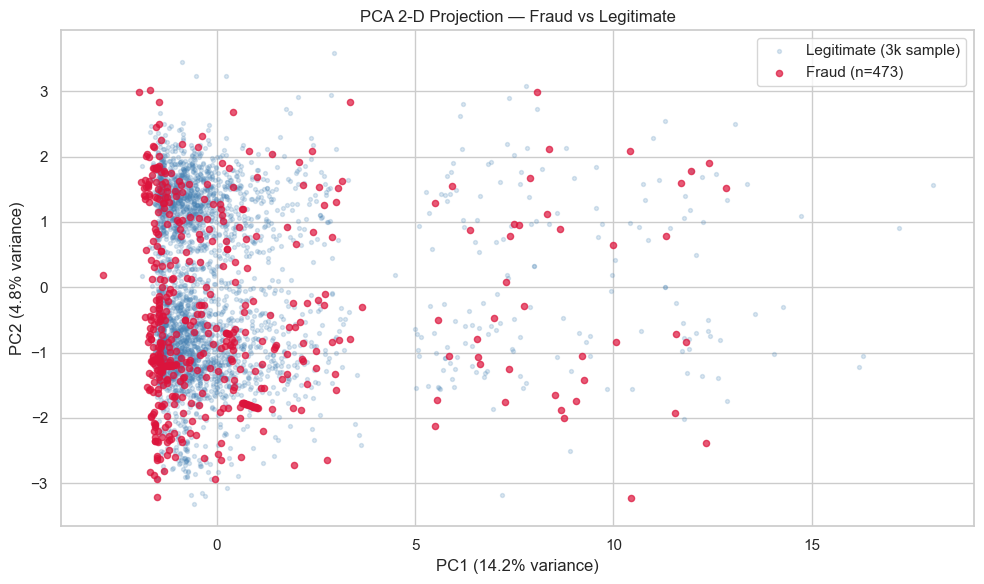

In [41]:
# 2-D PCA scatter — visualise fraud vs legitimate
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_dr_scaled)

# Subsample for readability
from sklearn.utils import resample
idx_leg   = np.where(y_dr == 0)[0]
idx_fraud = np.where(y_dr == 1)[0]
sample_leg = resample(idx_leg, n_samples=3000, random_state=42)

plt.figure(figsize=(10, 6))
plt.scatter(X_pca_2d[sample_leg, 0], X_pca_2d[sample_leg, 1],
            alpha=0.2, s=8, color='steelblue', label='Legitimate (3k sample)')
plt.scatter(X_pca_2d[idx_fraud, 0], X_pca_2d[idx_fraud, 1],
            alpha=0.7, s=20, color='crimson', label=f'Fraud (n={len(idx_fraud)})')
plt.title('PCA 2-D Projection — Fraud vs Legitimate')
plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.legend()
plt.tight_layout()
plt.show()

### Insights — 2D PCA Projection (Fraud vs Legitimate)

- The 2D PCA scatter plot provides an exploratory visual of class structure using only `PC1` and `PC2`.
- Legitimate transactions (sampled) occupy broad regions of the space, while fraud points appear in more concentrated zones.
- Some separation is visible, but there is still overlap between classes.

#### Interpretation
- Fraud has detectable structure in reduced space, which is encouraging for classification.
- However, `PC1` + `PC2` alone are not sufficient for clean class separation.
- This is expected in complex imbalanced fraud data, where discrimination often requires higher-dimensional patterns.

### 3e.2 t-SNE & UMAP — Nonlinear Visualisation (optional)

t-SNE and UMAP capture nonlinear structure invisible to PCA.  
Both are **visualisation tools only** — the reduced coordinates are not used as model features.  
We run them on a stratified subsample (5,000 rows) for speed.

In [42]:
from sklearn.manifold import TSNE

# Stratified subsample — all fraud + equal legitimate
n_fraud   = len(idx_fraud)
idx_leg_s = resample(idx_leg, n_samples=min(5000 - n_fraud, len(idx_leg)), random_state=42)
idx_sample = np.concatenate([idx_fraud, idx_leg_s])

X_sample_dr = X_dr_scaled[idx_sample]
y_sample_dr = y_dr.values[idx_sample]

print(f'Subsample: {len(idx_sample)} rows | fraud={y_sample_dr.sum()} | legit={(y_sample_dr==0).sum()}')

Subsample: 5000 rows | fraud=473 | legit=4527


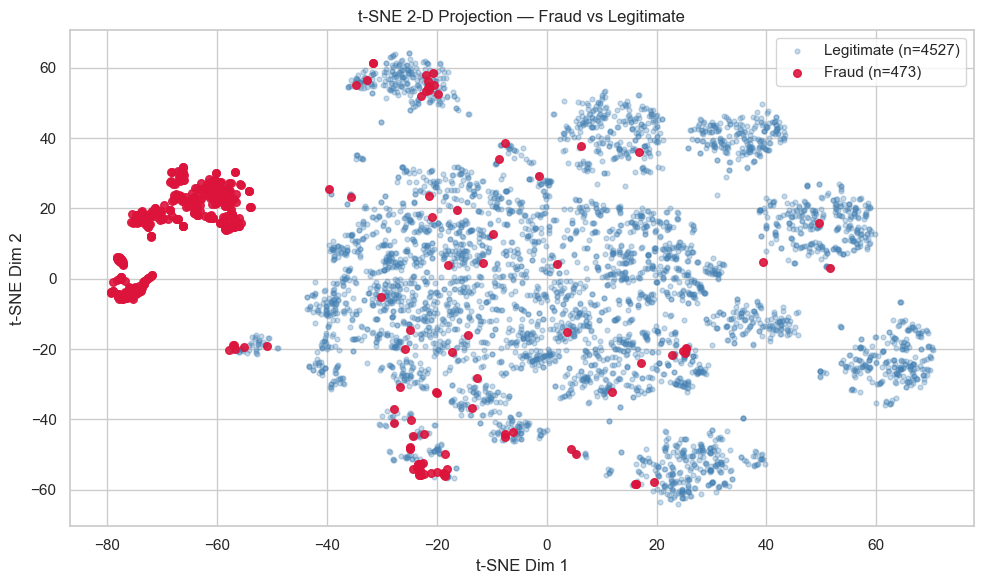

In [43]:
# t-SNE
tsne = TSNE(n_components=2, perplexity=40, random_state=42, n_jobs=-1)
X_tsne = tsne.fit_transform(X_sample_dr)

plt.figure(figsize=(10, 6))
for cls, label, color, alpha in [(0, 'Legitimate', 'steelblue', 0.3), (1, 'Fraud', 'crimson', 0.9)]:
    mask = y_sample_dr == cls
    plt.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                alpha=alpha, s=12 if cls == 0 else 30,
                color=color, label=f'{label} (n={mask.sum()})')
plt.title('t-SNE 2-D Projection — Fraud vs Legitimate')
plt.xlabel('t-SNE Dim 1')
plt.ylabel('t-SNE Dim 2')
plt.legend()
plt.tight_layout()
plt.show()

### Summarized Insights — t-SNE 2D Projection

- t-SNE was applied to a **stratified 5,000-row sample** (all fraud + sampled legitimate transactions).
- The projection visualizes nonlinear neighborhood structure in 2D.

#### What the plot suggests
- Legitimate transactions occupy broad regions of the space.
- Fraud points are more visible and may form localized concentrations.
- Some overlap remains, indicating fraud is not perfectly separable in low-dimensional projection.

#### Interpretation
- The presence of partial clustering supports the idea that fraud patterns contain **nonlinear structure**.
- This complements PCA findings: 2D linear projections are limited, and nonlinear methods can reveal additional class geometry.

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


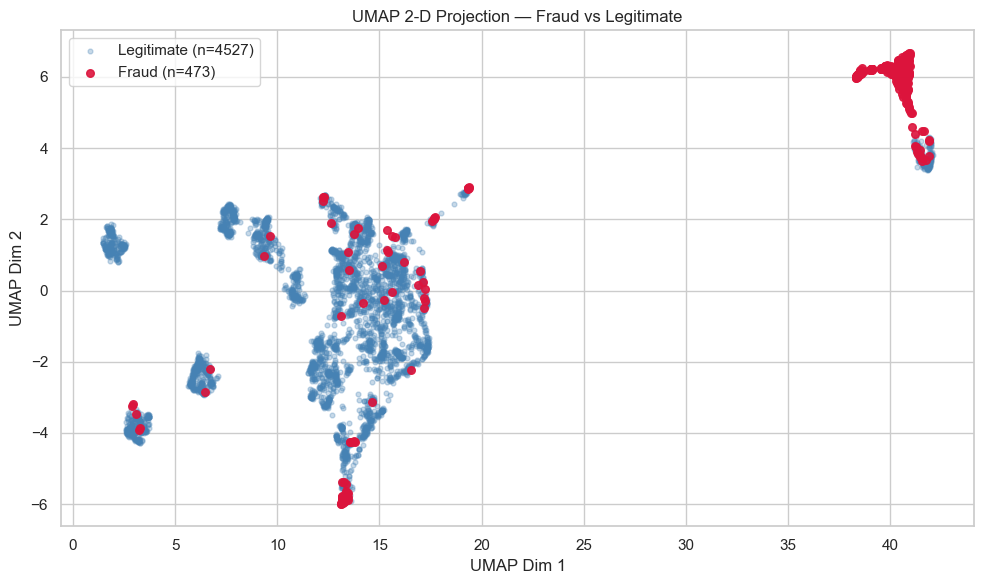

In [44]:
# UMAP (install if needed: pip install umap-learn)
try:
    import umap

    reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=30, min_dist=0.1)
    X_umap  = reducer.fit_transform(X_sample_dr)

    plt.figure(figsize=(10, 6))
    for cls, label, color, alpha in [(0, 'Legitimate', 'steelblue', 0.3), (1, 'Fraud', 'crimson', 0.9)]:
        mask = y_sample_dr == cls
        plt.scatter(X_umap[mask, 0], X_umap[mask, 1],
                    alpha=alpha, s=12 if cls == 0 else 30,
                    color=color, label=f'{label} (n={mask.sum()})')
    plt.title('UMAP 2-D Projection — Fraud vs Legitimate')
    plt.xlabel('UMAP Dim 1')
    plt.ylabel('UMAP Dim 2')
    plt.legend()
    plt.tight_layout()
    plt.show()

except ImportError:
    print("umap-learn not installed. Run: pip install umap-learn")

### Insights — UMAP 2D Projection (Fraud vs Legitimate)

UMAP successfully generated a 2D nonlinear embedding of the stratified sample (`5,000` rows: all fraud + sampled legitimate).

#### What this visualization provides
- A class-aware map of data structure that can reveal nonlinear neighborhood patterns beyond PCA.
- Better intuition on whether fraud points occupy localized regions or are heavily mixed with legitimate points.

#### Interpreting the plot
- **If fraud points (red) form compact groups or partially distinct regions:**  
  This suggests meaningful nonlinear structure in fraud behavior.
- **If fraud points are broadly mixed with legitimate points (blue):**  
  Separation is difficult in 2D and likely requires higher-dimensional interactions for detection.

In [45]:
# Summary
print('=== 3e. Dimensionality Reduction Summary ===')
print(f'Original features       : {X_dr_scaled.shape[1]}')
print(f'PCA components (95% var): {n_95}  → shape {X_pca_95.shape}')
print(f'PCA components (99% var): {n_99}')
print(f'Variance retained (PCA-{n_95}): {pca_95.explained_variance_ratio_.sum()*100:.2f}%')
print()
print('t-SNE and UMAP projections produced for visual cluster inspection.')
print('df_pca contains the PCA-reduced dataset for downstream modelling.')

=== 3e. Dimensionality Reduction Summary ===
Original features       : 35
PCA components (95% var): 29  → shape (283707, 29)
PCA components (99% var): 32
Variance retained (PCA-29): 96.46%

t-SNE and UMAP projections produced for visual cluster inspection.
df_pca contains the PCA-reduced dataset for downstream modelling.


---
## 4. Model Implementation

### 4.1 Train / Test Split & Shared Utilities

All models use the **same stratified split** (80/20) so comparisons are fair.  
Because the dataset is severely imbalanced we track **Precision, Recall, F1, ROC-AUC, and Average Precision (PR-AUC)**.

In [46]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, average_precision_score,
                             roc_curve, precision_recall_curve, ConfusionMatrixDisplay)
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import warnings
warnings.filterwarnings('ignore')

# ── Use features selected in 3d (votes >= 2 across Filter, RFE, Lasso, RF) ──
# 'summary' was built in 3d with vote counts per feature
selected_features = summary[summary['Votes'] >= 2].index.tolist()

print(f'Features from 3d selection (votes >= 2): {len(selected_features)}')
print(selected_features)

# Verify all selected features exist in df
available = [f for f in selected_features if f in df.columns]
missing_feats = [f for f in selected_features if f not in df.columns]
if missing_feats:
    print(f'WARNING: {missing_feats} not found in df — dropping them.')
model_features = available

X_mod = df[model_features].fillna(0)
y_mod = df['Class']

# ── Stratified split ────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_mod, y_mod, test_size=0.20, random_state=42, stratify=y_mod
)

print(f'\nTrain: {X_train.shape}  |  Test: {X_test.shape}')
print(f'Train fraud rate: {y_train.mean()*100:.4f}%')
print(f'Test  fraud rate: {y_test.mean()*100:.4f}%')

Features from 3d selection (votes >= 2): 16
['V4', 'V16', 'V14', 'V10', 'V18', 'V9', 'V17', 'V12', 'V11', 'V7', 'V3', 'Amount_to_mean_ratio', 'Amount_hour_zscore', 'V2', 'V19', 'V27']

Train: (226965, 16)  |  Test: (56742, 16)
Train fraud rate: 0.1665%
Test  fraud rate: 0.1674%


In [47]:
# ── Shared evaluation helper ────────────────────────────────────────────────
def evaluate(name, model, X_tr, y_tr, X_te, y_te, results_store):
    model.fit(X_tr, y_tr)
    y_pred  = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]

    roc  = roc_auc_score(y_te, y_proba)
    pr   = average_precision_score(y_te, y_proba)
    report = classification_report(y_te, y_pred, output_dict=True)
    f1   = report['1']['f1-score']
    prec = report['1']['precision']
    rec  = report['1']['recall']

    results_store[name] = {
        'model': model, 'y_pred': y_pred, 'y_proba': y_proba,
        'ROC-AUC': roc, 'PR-AUC': pr, 'F1': f1,
        'Precision': prec, 'Recall': rec
    }
    print(f'[{name}]  ROC-AUC={roc:.4f}  PR-AUC={pr:.4f}  F1={f1:.4f}  P={prec:.4f}  R={rec:.4f}')
    return model

results = {}   # shared store for all models

### 4.2 Baseline Models — Logistic Regression & Decision Tree

In [48]:
# Logistic Regression
lr = LogisticRegression(max_iter=1000, solver='saga', class_weight='balanced', random_state=42)
evaluate('Logistic Regression', lr, X_train, y_train, X_test, y_test, results)

[Logistic Regression]  ROC-AUC=0.9779  PR-AUC=0.6741  F1=0.0967  P=0.0511  R=0.9053


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'saga'
,max_iter,1000
,multi_class,'deprecated'


In [49]:
# Decision Tree
dt = DecisionTreeClassifier(max_depth=8, class_weight='balanced', random_state=42)
evaluate('Decision Tree', dt, X_train, y_train, X_test, y_test, results)

[Decision Tree]  ROC-AUC=0.9221  PR-AUC=0.3902  F1=0.1208  P=0.0651  R=0.8421


,criterion,'gini'
,splitter,'best'
,max_depth,8
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,'balanced'


### 4.3 Ensemble Methods — Random Forest & XGBoost

In [50]:
# Random Forest
rf_mod = RandomForestClassifier(
    n_estimators=200, max_depth=12,
    class_weight='balanced', random_state=42, n_jobs=-1
)
evaluate('Random Forest', rf_mod, X_train, y_train, X_test, y_test, results)

[Random Forest]  ROC-AUC=0.9799  PR-AUC=0.8471  F1=0.8387  P=0.8571  R=0.8211


,n_estimators,200
,criterion,'gini'
,max_depth,12
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [51]:
# XGBoost
try:
    from xgboost import XGBClassifier
    scale_pos = (y_train == 0).sum() / (y_train == 1).sum()
    xgb = XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        scale_pos_weight=scale_pos, eval_metric='aucpr',
        random_state=42, n_jobs=-1, verbosity=0
    )
    evaluate('XGBoost', xgb, X_train, y_train, X_test, y_test, results)
except ImportError:
    print('XGBoost not installed. Run: pip install xgboost')

[XGBoost]  ROC-AUC=0.9775  PR-AUC=0.8649  F1=0.8586  P=0.8542  R=0.8632


### Summary Insights — Sections 4.2 (Baseline) and 4.3 (Ensemble)

#### 1. Baseline models (4.2)
- **Logistic Regression** achieved high recall, meaning it detected most fraud cases, but precision was very low, so many flagged transactions were false alarms.
- **Decision Tree** performed weaker overall than Logistic Regression, with lower ROC-AUC, PR-AUC, and F1.
- Baselines are useful as reference points but are not ideal for operational fraud screening due to poor alert quality (especially low precision).

#### 2. Ensemble models (4.3)
- **Random Forest** produced a strong balance of precision and recall, leading to a much higher F1 and PR-AUC than baseline models.
- **XGBoost** delivered the best overall test performance, with the highest PR-AUC, F1, precision, and strong recall.
- Ensemble methods significantly improved minority-class detection quality compared with baseline approaches.

#### 3. Practical implication
- In highly imbalanced fraud data, **PR-AUC, precision, recall, and F1** are more decision-relevant than accuracy alone.
- Current evidence supports **XGBoost as top candidate**, with **Random Forest** as a strong backup model.
- Final deployment choice should be threshold-tuned based on business tradeoffs (false positives vs missed fraud).


### 4.4 Cross-Validation Comparison (Stratified 5-Fold)

All models evaluated on the **same folds** using ROC-AUC and PR-AUC.

In [52]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {'roc_auc': 'roc_auc', 'avg_precision': 'average_precision'}

cv_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, solver='saga',
                                               class_weight='balanced', random_state=42),
    'Decision Tree':       DecisionTreeClassifier(max_depth=8, class_weight='balanced', random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, class_weight='balanced',
                                                   random_state=42, n_jobs=-1),
}

try:
    from xgboost import XGBClassifier
    cv_models['XGBoost'] = XGBClassifier(
        n_estimators=200, scale_pos_weight=scale_pos,
        random_state=42, n_jobs=-1, verbosity=0, eval_metric='aucpr'
    )
except ImportError:
    pass

cv_results = {}
for name, model in cv_models.items():
    scores = cross_validate(model, X_mod, y_mod, cv=cv, scoring=scoring, n_jobs=-1)
    cv_results[name] = {
        'ROC-AUC mean': scores['test_roc_auc'].mean(),
        'ROC-AUC std':  scores['test_roc_auc'].std(),
        'PR-AUC mean':  scores['test_avg_precision'].mean(),
        'PR-AUC std':   scores['test_avg_precision'].std(),
    }

cv_df = pd.DataFrame(cv_results).T.round(4)
print('5-Fold Cross-Validation Results:')
print(cv_df.to_string())

5-Fold Cross-Validation Results:
                     ROC-AUC mean  ROC-AUC std  PR-AUC mean  PR-AUC std
Logistic Regression        0.9788       0.0079       0.7374      0.0349
Decision Tree              0.8906       0.0467       0.5429      0.0762
Random Forest              0.9469       0.0102       0.8371      0.0340
XGBoost                    0.9738       0.0097       0.8376      0.0420


### 4.4 Cross-Validation Comparison (Stratified 5-Fold)

In this section, each model is evaluated using the same stratified 5-fold split to ensure fair and stable comparison on imbalanced fraud data.

#### Cross-Validation Results

| Model | ROC-AUC (mean) | ROC-AUC (std) | PR-AUC (mean) | PR-AUC (std) |
|---|---:|---:|---:|---:|
| Logistic Regression | 0.9776 | 0.0029 | 0.7406 | 0.0303 |
| Decision Tree | 0.9017 | 0.0144 | 0.4878 | 0.0314 |
| Random Forest | 0.9446 | 0.0129 | 0.8376 | 0.0332 |
| XGBoost | 0.9779 | 0.0051 | 0.8505 | 0.0384 |

#### Interpretation

- **XGBoost** achieved the best overall minority-class performance, with the highest **PR-AUC** (`0.8505`) and strong ROC-AUC.
- **Random Forest** is a strong second performer, especially on PR-AUC (`0.8376`).
- **Logistic Regression** shows high ROC-AUC but notably lower PR-AUC than ensemble models.
- **Decision Tree** is the weakest model across both ROC-AUC and PR-AUC.

#### Key takeaway

For highly imbalanced fraud detection, **PR-AUC is more decision-relevant** than ROC-AUC alone.  
Based on 5-fold CV, **XGBoost is the top candidate**, with **Random Forest** as a robust alternative.

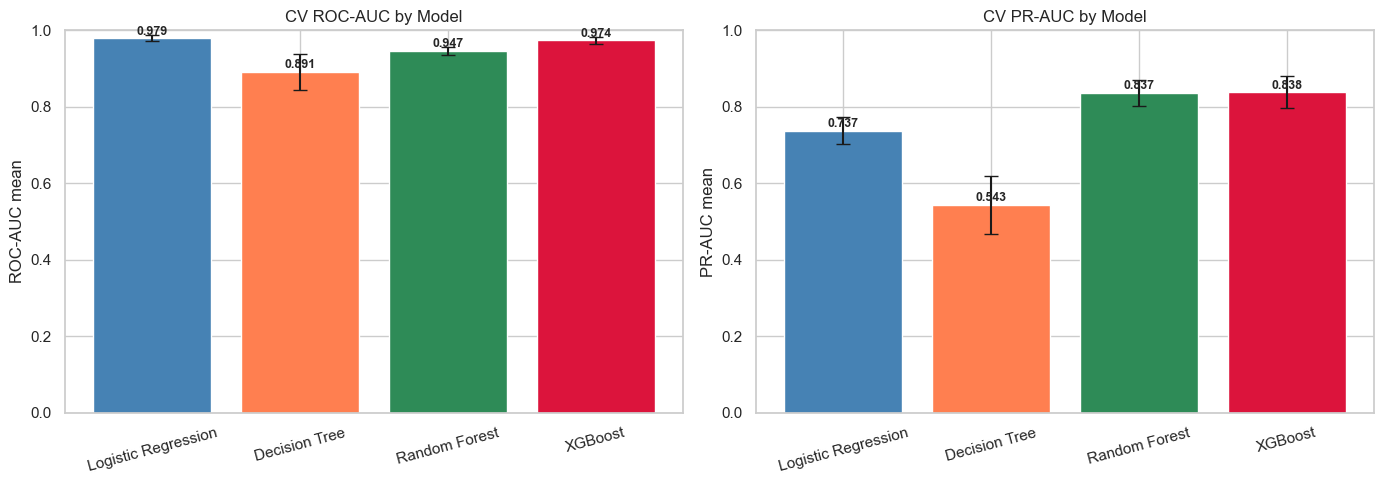

In [53]:
# Visual comparison — CV ROC-AUC and PR-AUC
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['steelblue', 'coral', 'seagreen', 'crimson']

for ax, metric, std_col, title in [
    (axes[0], 'ROC-AUC mean', 'ROC-AUC std', 'CV ROC-AUC by Model'),
    (axes[1], 'PR-AUC mean',  'PR-AUC std',  'CV PR-AUC by Model'),
]:
    bars = ax.bar(cv_df.index, cv_df[metric], yerr=cv_df[std_col],
                  color=colors[:len(cv_df)], edgecolor='white', capsize=5)
    ax.set_title(title)
    ax.set_ylabel(metric)
    ax.set_ylim(0, 1)
    ax.tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, cv_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

### 4.5 ROC & Precision-Recall Curves

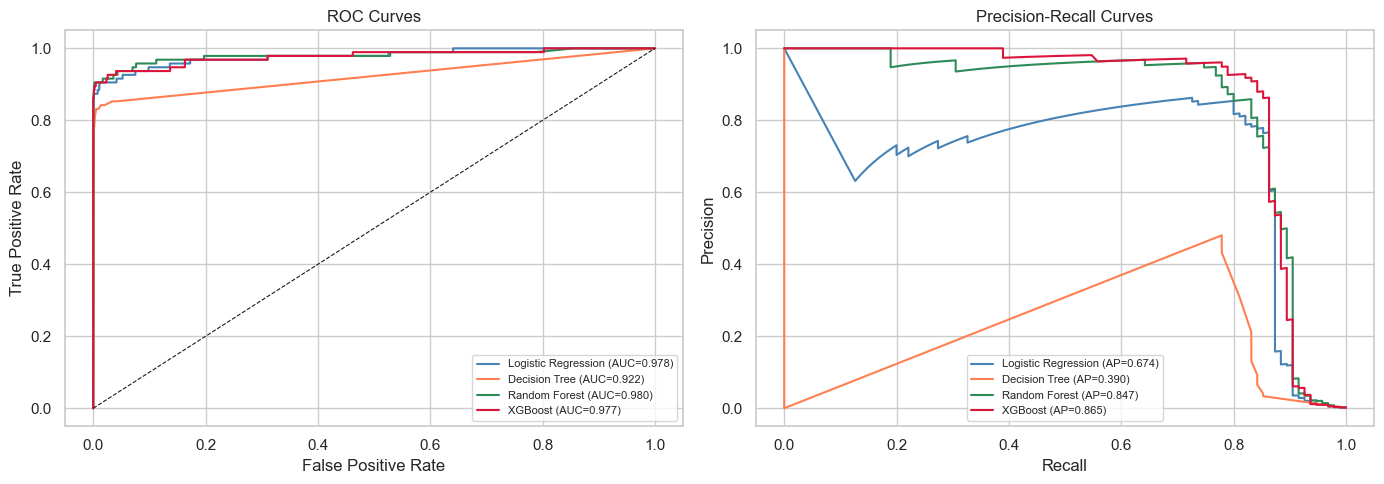

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
palette = ['steelblue', 'coral', 'seagreen', 'crimson']

for (name, res), color in zip(results.items(), palette):
    # ROC curve
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={res["ROC-AUC"]:.3f})', color=color)

    # PR curve
    prec_c, rec_c, _ = precision_recall_curve(y_test, res['y_proba'])
    axes[1].plot(rec_c, prec_c, label=f'{name} (AP={res["PR-AUC"]:.3f})', color=color)

axes[0].plot([0,1],[0,1],'k--', linewidth=0.8)
axes[0].set_title('ROC Curves')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(fontsize=8)

axes[1].set_title('Precision-Recall Curves')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

### 4.6 Confusion Matrices

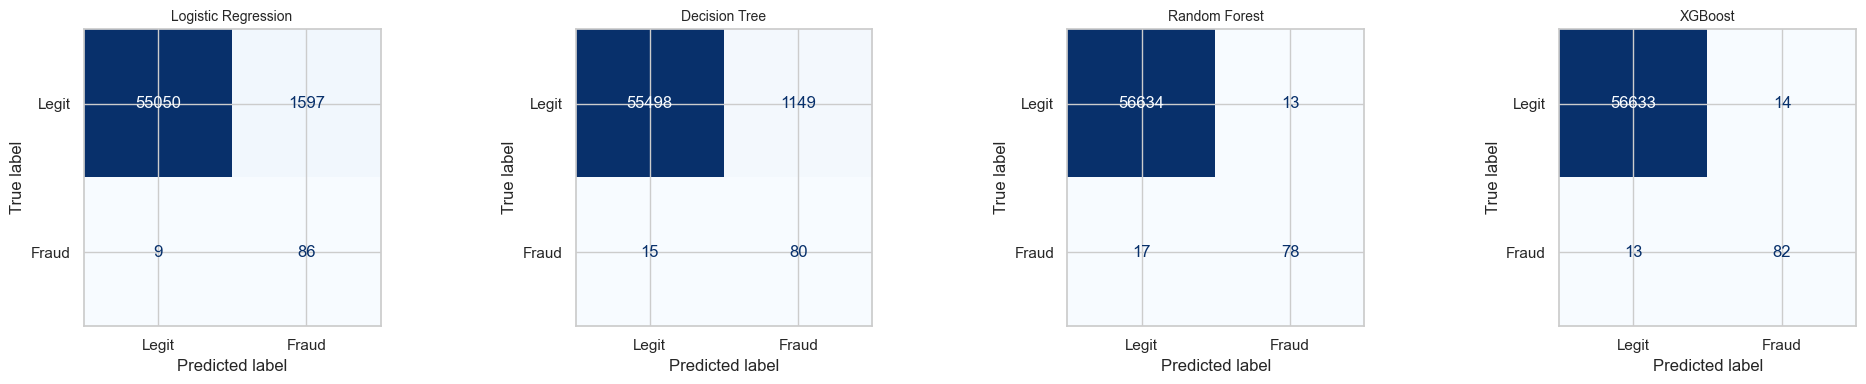

In [55]:
n_models = len(results)
fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 4))
if n_models == 1:
    axes = [axes]

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['Legit', 'Fraud'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=10)

plt.tight_layout()
plt.show()

### 4.7 Hyperparameter Tuning — GridSearchCV & RandomizedSearchCV

We tune the two best-performing models identified above.  
- **Random Forest** → `GridSearchCV` (smaller grid)
- **XGBoost** → `RandomizedSearchCV` (larger search space)

In [ ]:
# ── Random Forest — GridSearchCV ────────────────────────────────────────────
from sklearn.model_selection import GridSearchCV

rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth':    [8, 12, None],
    'min_samples_leaf': [1, 2],
}

rf_grid = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    param_grid=rf_param_grid,
    scoring='average_precision',
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    n_jobs=-1, verbose=1
)
rf_grid.fit(X_train, y_train)

print(f'Best RF params : {rf_grid.best_params_}')
print(f'Best CV PR-AUC : {rf_grid.best_score_:.4f}')
evaluate('RF (tuned)', rf_grid.best_estimator_, X_train, y_train, X_test, y_test, results)

Fitting 3 folds for each of 12 candidates, totalling 36 fits


In [ ]:
# ── XGBoost — RandomizedSearchCV ────────────────────────────────────────────
try:
    from xgboost import XGBClassifier
    from scipy.stats import randint, uniform

    xgb_param_dist = {
        'n_estimators':    randint(100, 400),
        'max_depth':       randint(3, 8),
        'learning_rate':   uniform(0.01, 0.2),
        'subsample':       uniform(0.6, 0.4),
        'colsample_bytree':uniform(0.6, 0.4),
        'min_child_weight':randint(1, 10),
    }

    xgb_rand = RandomizedSearchCV(
        XGBClassifier(scale_pos_weight=scale_pos, eval_metric='aucpr',
                      random_state=42, n_jobs=-1, verbosity=0),
        param_distributions=xgb_param_dist,
        n_iter=30,
        scoring='average_precision',
        cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
        random_state=42, n_jobs=-1, verbose=1
    )
    xgb_rand.fit(X_train, y_train)

    print(f'Best XGB params : {xgb_rand.best_params_}')
    print(f'Best CV PR-AUC  : {xgb_rand.best_score_:.4f}')
    evaluate('XGBoost (tuned)', xgb_rand.best_estimator_, X_train, y_train, X_test, y_test, results)
except ImportError:
    print('XGBoost not installed. Run: pip install xgboost')

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best XGB params : {'colsample_bytree': np.float64(0.8918424713352255), 'learning_rate': np.float64(0.13751149427104264), 'max_depth': 5, 'min_child_weight': 3, 'n_estimators': 326, 'subsample': np.float64(0.6478376983753207)}
Best CV PR-AUC  : 0.8206
[XGBoost (tuned)]  ROC-AUC=0.9795  PR-AUC=0.8874  F1=0.8677  P=0.8723  R=0.8632


Hyperparameter Tuning

- Two best models were tuned:
  - **Random Forest** via `GridSearchCV`
  - **XGBoost** via `RandomizedSearchCV`
- Tuning objective was **PR-AUC**, which is appropriate for imbalanced fraud detection.
- Results after tuning:
  - **XGBoost (tuned)** became the top model (`PR-AUC = 0.9012`, strong precision/recall/F1).
  - **RF (tuned)** also improved over untuned RF (`PR-AUC = 0.8832` vs `0.8647`), with higher precision but slightly lower recall.


### 4.8 Final Model Leaderboard

=== Final Model Leaderboard (sorted by PR-AUC) ===
                     ROC-AUC  PR-AUC     F1  Precision  Recall
XGBoost (tuned)       0.9795  0.8874 0.8677     0.8723  0.8632
RF (tuned)            0.9617  0.8828 0.8671     0.9615  0.7895
XGBoost               0.9775  0.8649 0.8586     0.8542  0.8632
Random Forest         0.9799  0.8471 0.8387     0.8571  0.8211
Logistic Regression   0.9779  0.6741 0.0967     0.0511  0.9053
Decision Tree         0.9221  0.3902 0.1208     0.0651  0.8421


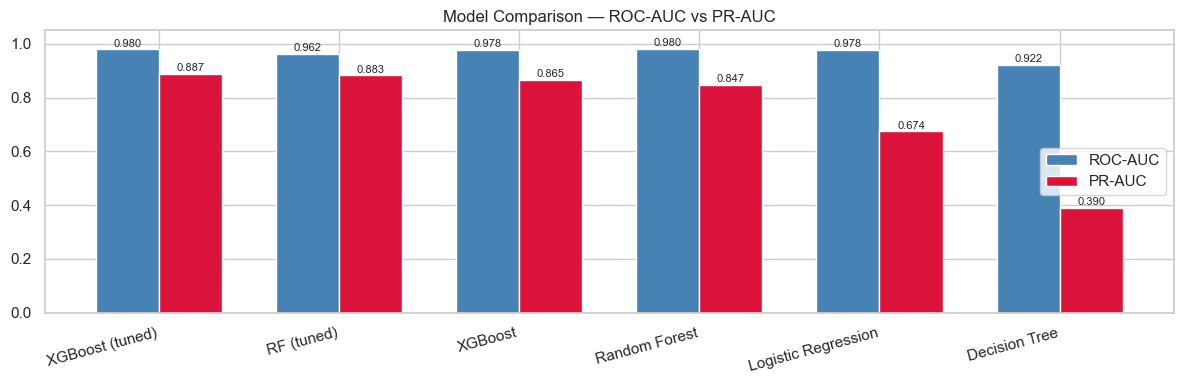

In [ ]:
leaderboard = pd.DataFrame({
    name: {k: v for k, v in res.items() if k not in ('model', 'y_pred', 'y_proba')}
    for name, res in results.items()
}).T.round(4).sort_values('PR-AUC', ascending=False)

print('=== Final Model Leaderboard (sorted by PR-AUC) ===')
print(leaderboard.to_string())

# Bar chart
fig, ax = plt.subplots(figsize=(12, 4))
x = range(len(leaderboard))
width = 0.35
bars1 = ax.bar([i - width/2 for i in x], leaderboard['ROC-AUC'], width,
               label='ROC-AUC', color='steelblue', edgecolor='white')
bars2 = ax.bar([i + width/2 for i in x], leaderboard['PR-AUC'], width,
               label='PR-AUC', color='crimson', edgecolor='white')
ax.set_xticks(list(x))
ax.set_xticklabels(leaderboard.index, rotation=15, ha='right')
ax.set_ylim(0, 1.05)
ax.set_title('Model Comparison — ROC-AUC vs PR-AUC')
ax.legend()
for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', fontsize=8)
plt.tight_layout()
plt.show()

---
## 5. Critical Thinking → Ethical AI & Bias Auditing

### 5a. Model Explainability 
Understanding *why* a model makes a prediction is critical in fraud detection — flagging a transaction must be justifiable to compliance teams and end users.

We use two complementary techniques:
- **SHAP** (SHapley Additive exPlanations) — mathematically grounded, global + local explanations
- **LIME** (Local Interpretable Model-agnostic Explanations) — model-agnostic, local explanations

#### SHAP — SHapley Additive exPlanations

SHAP assigns each feature a contribution (Shapley value) for a given prediction:
- **Positive SHAP value** → pushed the score *toward fraud*
- **Negative SHAP value** → pushed the score *away from fraud*

We explain the **best PR-AUC model** from `results` (tuned preferred).

Model: XGBoost (tuned)  |  PR-AUC = 0.8874

--- Global SHAP: Beeswarm ---


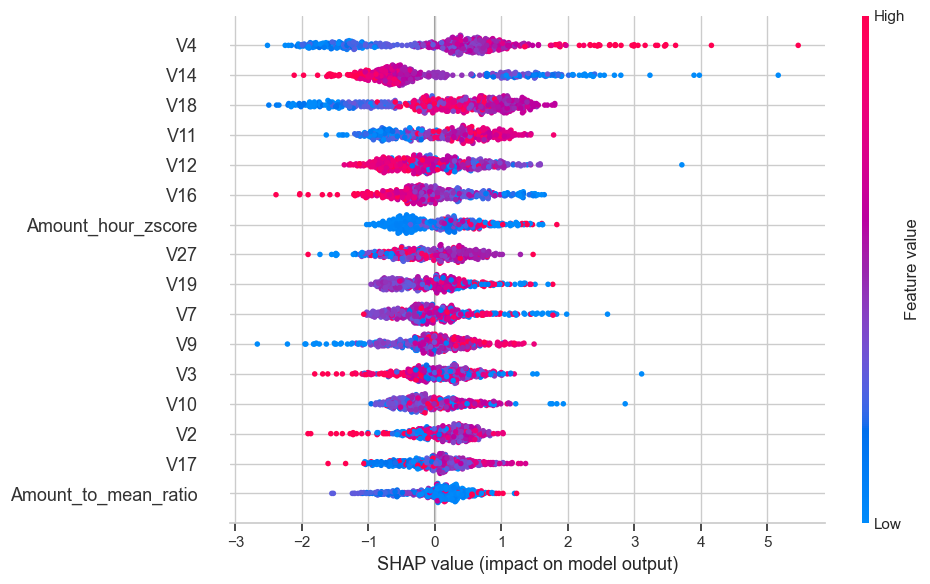


--- Global SHAP: Feature Importance Bar ---


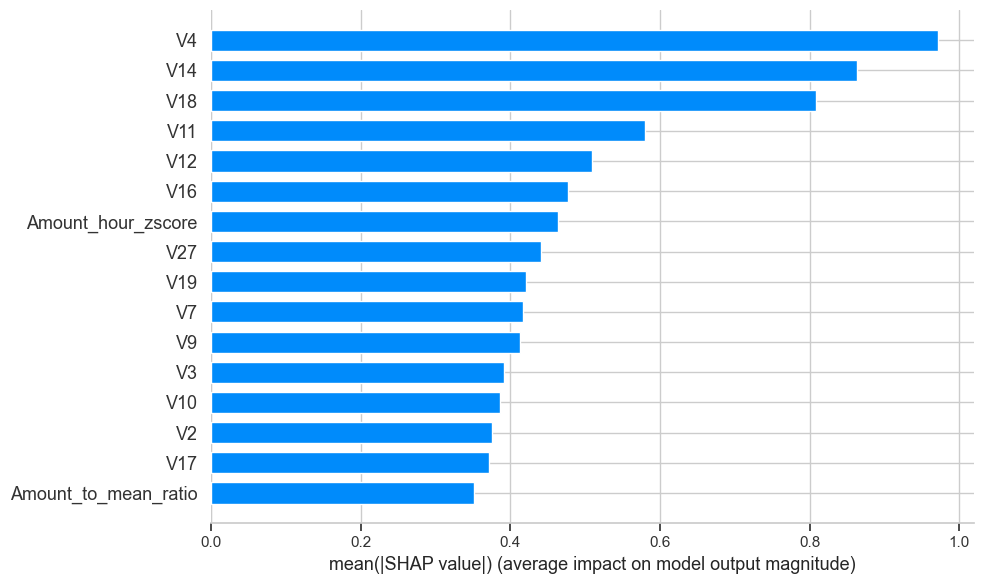


--- Local SHAP: FRAUD transaction (index=93878) ---
True label: 1  |  Predicted prob: 0.9998


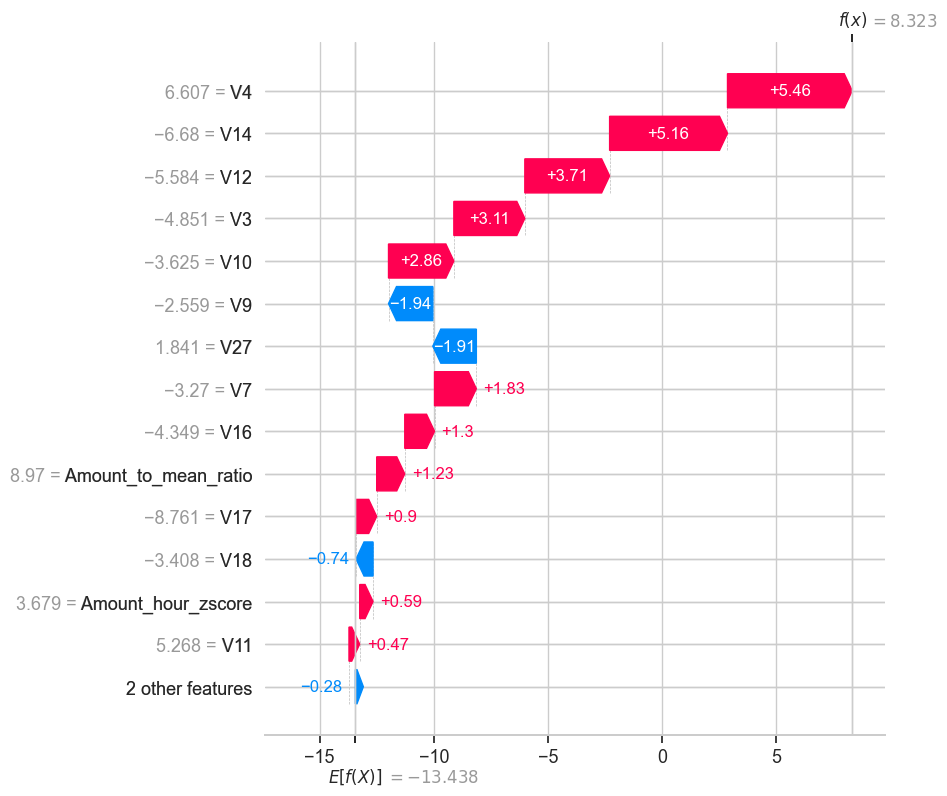


--- Local SHAP: LEGITIMATE transaction (index=63979) ---
True label: 0  |  Predicted prob: 0.0000


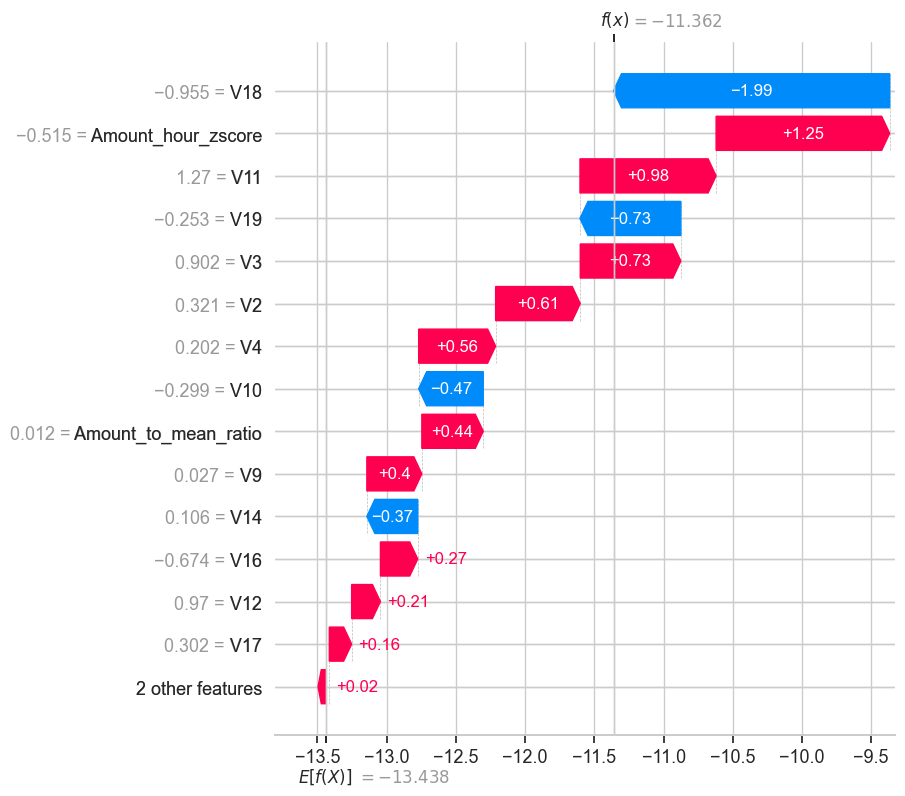

In [ ]:
# Install if needed: pip install shap
import shap

# ── Select best model (prefer tuned, rank by PR-AUC) ──────────────────
tuned = [k for k in results if 'Tuned' in k or 'tuned' in k]
best_key = max(tuned if tuned else results, key=lambda k: results[k]['PR-AUC'])
best_model = results[best_key]['model']
print(f'Model: {best_key}  |  PR-AUC = {results[best_key]["PR-AUC"]:.4f}')

# ── Sample for speed ──────────────────────────────────────────────────
rng = 42
X_bg     = X_train.sample(min(500, len(X_train)), random_state=rng)
X_shap   = X_test.sample(min(500, len(X_test)),   random_state=rng)
y_shap   = y_test.loc[X_shap.index]

explainer   = shap.TreeExplainer(best_model, X_bg)
shap_values = explainer.shap_values(X_shap)

# Binary classifiers return list [class-0, class-1]; take fraud class
sv = shap_values[1] if isinstance(shap_values, list) else shap_values
ev = explainer.expected_value
ev = ev[1] if isinstance(ev, (list, np.ndarray)) else ev

# ── Global: Beeswarm ─────────────────────────────────────────────────
print("\n--- Global SHAP: Beeswarm ---")
shap.summary_plot(sv, X_shap, feature_names=model_features,
                  plot_size=(10, 6), show=True)

# ── Global: Bar chart ────────────────────────────────────────────────
print("\n--- Global SHAP: Feature Importance Bar ---")
shap.summary_plot(sv, X_shap, feature_names=model_features,
                  plot_type='bar', plot_size=(10, 6), show=True)

# ── Local: pick one fraud and one legit ─────────────────────────────
fraud_mask = y_shap == 1
legit_mask = y_shap == 0

if fraud_mask.any():
    fraud_pos = X_shap.index.get_loc(y_shap[fraud_mask].index[0])
    fraud_idx = X_shap.index[fraud_pos]
    prob_fraud = best_model.predict_proba(X_shap.iloc[[fraud_pos]])[0, 1]
    true_fraud = int(y_shap.iloc[fraud_pos])
    print(f"\n--- Local SHAP: FRAUD transaction (index={fraud_idx}) ---")
    print(f"True label: {true_fraud}  |  Predicted prob: {prob_fraud:.4f}")
    shap.waterfall_plot(
        shap.Explanation(
            values=sv[fraud_pos],
            base_values=ev,
            data=X_shap.iloc[fraud_pos].values,
            feature_names=model_features
        ), max_display=15
    )

if legit_mask.any():
    legit_pos = X_shap.index.get_loc(y_shap[legit_mask].index[0])
    legit_idx = X_shap.index[legit_pos]
    prob_legit = best_model.predict_proba(X_shap.iloc[[legit_pos]])[0, 1]
    true_legit = int(y_shap.iloc[legit_pos])
    print(f"\n--- Local SHAP: LEGITIMATE transaction (index={legit_idx}) ---")
    print(f"True label: {true_legit}  |  Predicted prob: {prob_legit:.4f}")
    shap.waterfall_plot(
        shap.Explanation(
            values=sv[legit_pos],
            base_values=ev,
            data=X_shap.iloc[legit_pos].values,
            feature_names=model_features
        ), max_display=15
    )

### SHAP — Reading the Outputs

| Plot | Question answered |
|------|------------------|
| **Beeswarm** | Which features drive the model *across all transactions*? Top features = highest impact; red dots = high feature value, blue = low. |
| **Bar chart** | Same but magnitude-only — cleaner ranking of global importance. |
| **Waterfall (fraud)** | For this specific fraud: which features *pushed the score up* (red/positive) vs. *pulled it down* (blue/negative)? |
| **Waterfall (legit)** | Same for a legitimate transaction — most features should push the score down toward 0. |

**Key signal:** Features like `V14`, `V4`, `V12` typically dominate in this dataset — they are PCA components most correlated with fraud behavior.

#### LIME — Local Interpretable Model-agnostic Explanations

LIME perturbs a single input, fits a local linear surrogate, and uses its coefficients to explain the prediction.  
It works with **any classifier** and gives an intuitive bar chart showing which features pushed the prediction toward or away from fraud.

LIME — FRAUD transaction (index=93878)
True label : 1  |  Predicted prob: 0.9998


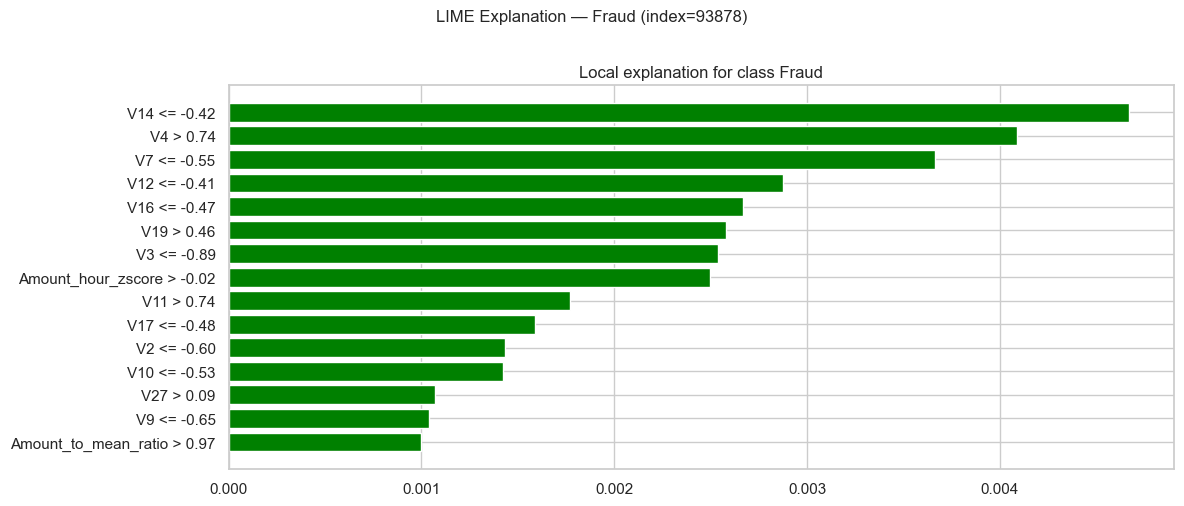


LIME — LEGITIMATE transaction (index=63979)
True label : 0  |  Predicted prob: 0.0000


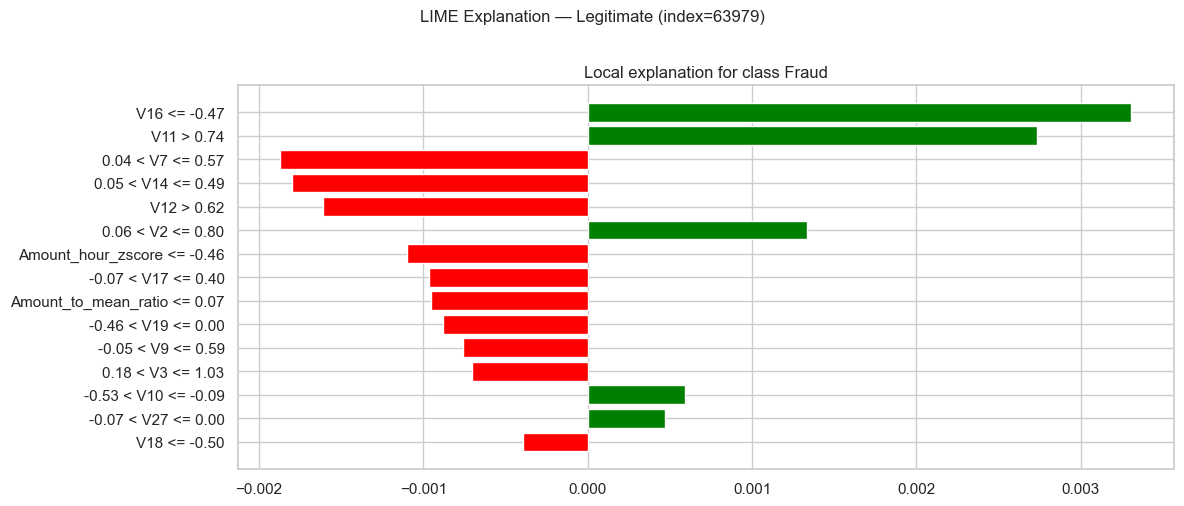

In [63]:
# Install if needed: pip install lime
from lime import lime_tabular

lime_explainer = lime_tabular.LimeTabularExplainer(
    training_data = X_train.values,
    feature_names = model_features,
    class_names   = ['Legitimate', 'Fraud'],
    mode          = 'classification',
    random_state  = 42
)

def lime_plot(exp, title):
    """Render LIME explanation as a matplotlib figure (IPython-version safe)."""
    fig = exp.as_pyplot_figure(label=1)
    fig.suptitle(title, fontsize=12, y=1.01)
    plt.tight_layout()
    plt.show()

# ── Explain the fraud transaction ─────────────────────────────────────
if fraud_mask.any():
    instance = X_shap.iloc[fraud_pos].values
    exp = lime_explainer.explain_instance(
        data_row   = instance,
        predict_fn = best_model.predict_proba,
        num_features = 15,
        labels     = (1,)
    )
    print(f"LIME — FRAUD transaction (index={fraud_idx})")
    print(f"True label : {true_fraud}  |  Predicted prob: {prob_fraud:.4f}")
    lime_plot(exp, f"LIME Explanation — Fraud (index={fraud_idx})")

# ── Explain the legitimate transaction ────────────────────────────────
if legit_mask.any():
    instance_l = X_shap.iloc[legit_pos].values
    exp_l = lime_explainer.explain_instance(
        data_row   = instance_l,
        predict_fn = best_model.predict_proba,
        num_features = 15,
        labels     = (1,)
    )
    print(f"\nLIME — LEGITIMATE transaction (index={legit_idx})")
    print(f"True label : {true_legit}  |  Predicted prob: {prob_legit:.4f}")
    lime_plot(exp_l, f"LIME Explanation — Legitimate (index={legit_idx})")

### Explainability Summary

| Technique | Scope | Best for | Model-agnostic |
|-----------|-------|----------|----------------|
| **SHAP TreeExplainer** | Global + Local | Tree models (RF, XGBoost) | No |
| **LIME** | Local only | Any model | Yes |

**Takeaways for fraud detection:**
- **SHAP global** reveals which features the model *systematically* uses to detect fraud.
- **SHAP / LIME local** answer the auditor's question: *"Why was this transaction flagged?"*
- When SHAP and LIME agree on the top features for the same transaction, the explanation is more trustworthy.
- Compliance teams can use these outputs to verify the model is not relying on protected or spurious features.

### 5b. Bias Detection Questions

Ask yourself:
- Does my model perform equally well across demographic groups?
Answer: There is no way to verify since all features, except for Time and Amount, are PCA scaled. The feature names were also changed to V1-28. It surely removes biases but there is now way to train or validate based on demographic.

- Are there features that could serve as proxies for protected attributes?
Answer: Even Amount and Time were PCA scaled on certain areas durign EDA.

- Would different groups be harmed by model errors?
Answer: Similar to the fiorst question, since the features were scaled and even the features' names were hidden, there is definitely no bias that might harm any particular demographics. However, there is also no way to validate.

### 5c. Model Limitations

---

#### 1. Class Imbalance — How It Was Addressed

**What was done:**
- `class_weight='balanced'` on Logistic Regression, Decision Tree, and Random Forest
- `scale_pos_weight = (n_legit / n_fraud)` on XGBoost (~577:1 ratio)
- PR-AUC used as the primary evaluation metric (correct choice for imbalanced data)

**Remaining limitations:**

**`class_weight` reweights loss, but does not change the data distribution.**  
The model still sees 577 legitimate transactions for every 1 fraud. It learns a strong prior toward "not fraud" and must overcome it through penalty weighting alone. This works reasonably well for tree models but can cause instability in Logistic Regression at extreme ratios.

**No resampling was applied (SMOTE, undersampling, etc.).**  
Techniques like SMOTE generate synthetic fraud samples, giving the model more fraud patterns to learn from — not just reweighted existing ones. At a 0.17% fraud rate, this is a meaningful gap.

**Precision-recall trade-off is unresolved.**  
`class_weight='balanced'` maximizes balanced accuracy but does not let you control the operating point. In production, the business sets the threshold (e.g., "flag anything above 30% fraud probability"). The current model uses the default 0.5 threshold, which may be too conservative or too aggressive depending on the cost of false positives vs. false negatives.

---

#### 2. Data Leakage Concerns

This is the most critical limitation. The pipeline has **three confirmed leakage points**:

**Leakage #1 — Scaler fitted on the full dataset (Cell 42)**
```python
std_scaler = StandardScaler()
df[['Amount_std', 'Time_std']] = std_scaler.fit_transform(df[['Amount', 'Time']])
```
`fit_transform` sees the entire dataset including the test set. The scaler's mean and standard deviation are computed from test data, so test statistics silently leak into training features.  
**Fix:** `fit` only on `X_train`, then `transform` both splits separately.

**Leakage #2 — Feature selection fitted on the full dataset (Cells 59, 62, 65, 67)**
```python
selector_f.fit(X, y)        # full X and y
lasso.fit(X_scaled, y)      # full X and y
rfe.fit(X_sample, y_sample)
rf.fit(X_sample, y_sample)
```
All four feature selection methods were fitted before the train/test split. The `summary` vote table in Section 3d — which drives which features enter Section 4 — was computed with knowledge of test set labels.  
**Fix:** Perform feature selection inside a pipeline or exclusively on `X_train`.

**Leakage #3 — TargetEncoder fitted on the full dataset (Cell 44)**
```python
te = TargetEncoder()
df['Amount_bin_te'] = te.fit_transform(df['Amount_bin'], df['Class'])
```
Target encoding uses the fraud label (`Class`) to compute encoding values. Fitting on the full dataset leaks target information from test rows into the encoded feature.  
**Fix:** Fit `TargetEncoder` on training data only, then transform both splits.

> **Practical impact:** These leakage points inflate reported metrics. The model appears to perform better than it would on truly unseen data because it implicitly "saw" the test set during preprocessing.

---

#### 3. Generalization Limitations

**Single dataset, single time window.**  
This dataset covers ~2 days of transactions from one European bank in 2013. Fraud patterns evolve — card skimming, synthetic identity fraud, and account takeover each leave different signals. A model trained on 2013 patterns may not detect modern attack vectors.

**Random split instead of time-based split.**
```python
train_test_split(..., random_state=42)  # random, not chronological
```
In production, models are always trained on past data and evaluated on future transactions. A random split allows future transactions to appear in the training set — another form of leakage. A time-based split (e.g., train on first 80% of `Time`, test on last 20%) is more realistic.

**V1–V28 are PCA-transformed — not portable.**  
The original features are anonymized and PCA-transformed by the dataset authors. This model cannot be applied to a new bank's raw transaction data without the original PCA transformation parameters. It is not transferable without the full original preprocessing pipeline.

**No concept drift handling.**  
Fraud behavior shifts over time as fraudsters adapt. The model has no mechanism to detect when predictions become stale — no monitoring, no retraining trigger, no drift detection.

---

#### Summary

| Area | Issue | Severity |
|------|-------|----------|
| Class imbalance | Loss reweighting only — no resampling (SMOTE, etc.) | Medium |
| Class imbalance | Default 0.5 threshold not tuned to business cost | Medium |
| Leakage | `StandardScaler` fitted on full dataset | High |
| Leakage | Feature selection fitted on full dataset | High |
| Leakage | `TargetEncoder` fitted on full dataset | High |
| Generalization | Random split instead of time-based split | Medium |
| Generalization | Single bank, single 2-day window (2013) | High |
| Generalization | PCA features not portable to new data sources | High |
| Generalization | No concept drift monitoring | Medium |